In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

print("Number of GPU: ", torch.cuda.device_count())
print("GPU Name: ", torch.cuda.get_device_name())


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Number of GPU:  1
GPU Name:  NVIDIA GeForce RTX 4070 Ti SUPER
Using device: cuda


In [3]:
# #place to pip install
# %pip install pandas 
# %pip install numpy
# %pip install seaborn
# %pip install matplotlib 
# %pip install scikit-learn
# %pip install statsmodels
# %pip install "scipy-stubs[scipy]"
# %pip install graphviz
# %pip install xgboost
# # command for checking packages you installed etc.
# !conda list
%pip install tensorflow

# # run this to ensure  running within conda environment
# import sys 
# sys.executable

Note: you may need to restart the kernel to use updated packages.


## Data Exploration

In [4]:
#imported libraries
import pandas as pd
import numpy as np
from uwb_dataset import import_from_files
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.fftpack import fft
import joblib #for saving and loading models

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dataset = import_from_files('../dataset/')
#load dataset from uwb script provided
df = pd.DataFrame(dataset)
print(f"Dataset shape: {df.shape}")


Processing file: ../dataset/uwb_dataset_part1.csv
Successfully loaded data from ../dataset/uwb_dataset_part1.csv
Processing file: ../dataset/uwb_dataset_part2.csv
Successfully loaded data from ../dataset/uwb_dataset_part2.csv
Processing file: ../dataset/uwb_dataset_part3.csv
Successfully loaded data from ../dataset/uwb_dataset_part3.csv
Processing file: ../dataset/uwb_dataset_part4.csv
Successfully loaded data from ../dataset/uwb_dataset_part4.csv
Processing file: ../dataset/uwb_dataset_part5.csv
Successfully loaded data from ../dataset/uwb_dataset_part5.csv
Processing file: ../dataset/uwb_dataset_part6.csv
Successfully loaded data from ../dataset/uwb_dataset_part6.csv
Processing file: ../dataset/uwb_dataset_part7.csv
Successfully loaded data from ../dataset/uwb_dataset_part7.csv
Successfully processed 7 files
Dataset shape: (42000, 1031)
Dataset shape: (42000, 1031)


In [6]:
#add in the attributes names to the combined dataset from all the csv files and stuff
column_names = [
    'NLOS',              # 1 if NLOS, 0 if LOS
    'measured_range',    # Measured range (time of flight)
    'RXPACC',           # received RX preamble symbols
    'FP_AMP1',          # first path amplitude - part1
    'FP_AMP2',          # first path amplitude - part2
    'FP_AMP3',          # first path amplitude - part3
    'STDEV_NOISE',      # standard deviation of noise
    'CIR_PWR',         # total channel impulse response power
    'MAX_NOISE',        # maximum value of noise
    'FP_IDX',          # first path index
    'CH',              # channel number
    'FRAME_LEN',       # length of frame
    'PREAM_LEN',       # preamble length
    'BITRATE',         # bitrate
    'PRFR'             # pulse repetition frequency rate in MHz
]

#add CIR column names (1016 samples)
cir_columns = [f'CIR_{i}' for i in range(1016)]
column_names.extend(cir_columns)

# rename DataFrame columns
df.columns = column_names

# find dtypes for each attribute
print("=== Data Types Analysis ===")
print("\nFeature Data Types:")

print(df.dtypes.head(15))

print("\n\nFeature describe:")
print(df.describe())

#see if total shape matches
print("\n\n Shape of total combined dataset:")
print("DataFrame shape:", df.shape)

df.head()
 


=== Data Types Analysis ===

Feature Data Types:
NLOS              float64
measured_range    float64
RXPACC            float64
FP_AMP1           float64
FP_AMP2           float64
FP_AMP3           float64
STDEV_NOISE       float64
CIR_PWR           float64
MAX_NOISE         float64
FP_IDX            float64
CH                float64
FRAME_LEN         float64
PREAM_LEN         float64
BITRATE           float64
PRFR              float64
dtype: object


Feature describe:
               NLOS  measured_range        RXPACC       FP_AMP1       FP_AMP2  \
count  42000.000000    42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000        3.831519    745.654167   8127.521905  11425.259524   
std        0.500006        2.355976      4.505024   5393.330697   6235.434769   
min        0.000000        0.000000    707.000000      7.000000     63.000000   
25%        0.000000        1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000        3.480000    74

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1006,CIR_1007,CIR_1008,CIR_1009,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


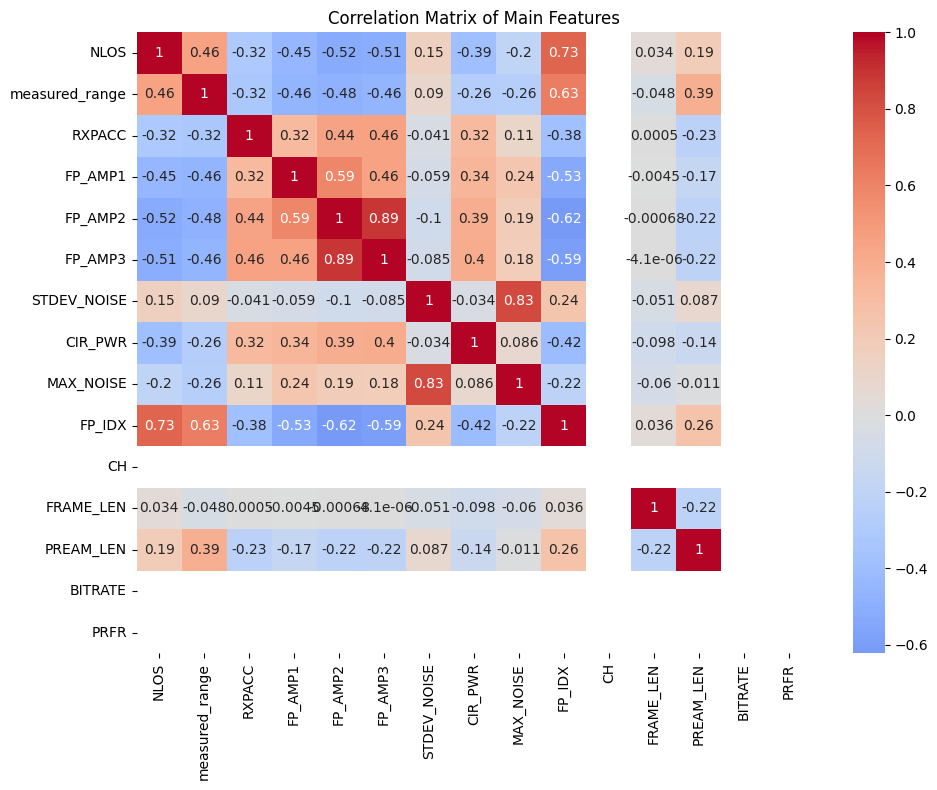

In [7]:
# correlation matrix visualisation (without CIR 1016 columns )

main_features = [
    'NLOS',              # 1 if NLOS, 0 if LOS
    'measured_range',    # Measured range (time of flight)
    'RXPACC',           # received RX preamble symbols
    'FP_AMP1',          # first path amplitude - part1
    'FP_AMP2',          # first path amplitude - part2
    'FP_AMP3',          # first path amplitude - part3
    'STDEV_NOISE',      # standard deviation of noise
    'CIR_PWR',         # total channel impulse response power
    'MAX_NOISE',        # maximum value of noise
    'FP_IDX',          # first path index
    'CH',              # channel number
    'FRAME_LEN',       # length of frame
    'PREAM_LEN',       # preamble length
    'BITRATE',         # bitrate
    'PRFR'             # pulse repetition frequency rate in MHz
]
# Create correlation matrix for main features
plt.figure(figsize=(10, 8))
correlation = df[main_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Main Features')
plt.tight_layout()
plt.show()

In [8]:
#distribution plot
cir_columns = [col for col in df.columns if 'CIR_' in col]

# Calculate summary features
df['CIR_mean'] = df[cir_columns].mean(axis=1)
df['CIR_std'] = df[cir_columns].std(axis=1)
df['CIR_max'] = df[cir_columns].max(axis=1)
df['CIR_energy'] = (df[cir_columns]**2).sum(axis=1)

## Visualisations for aggregation of mean,std,max for all CIR cols

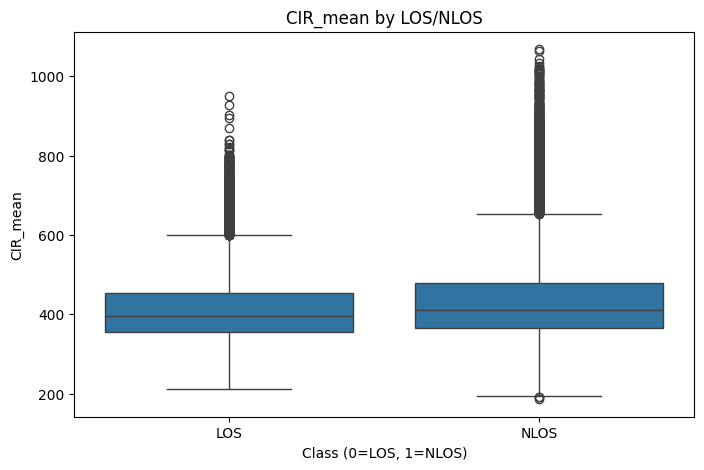

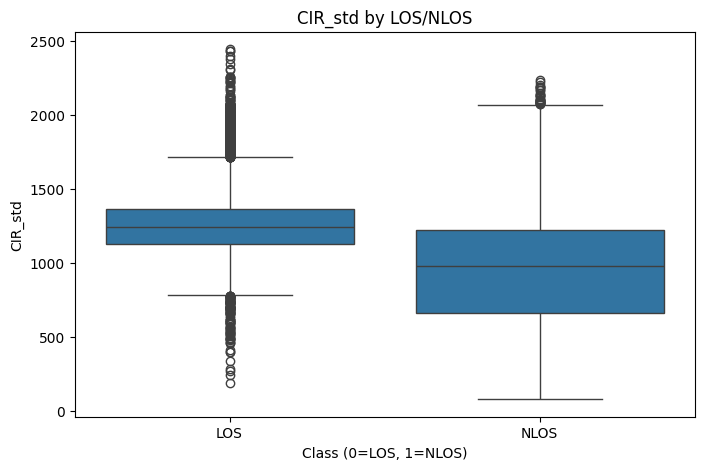

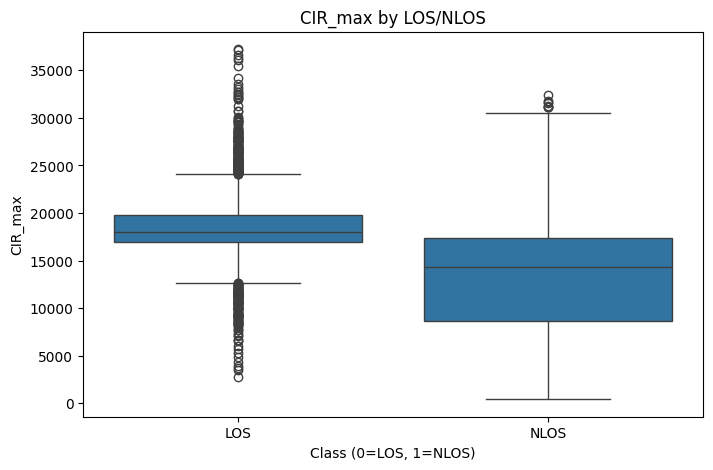

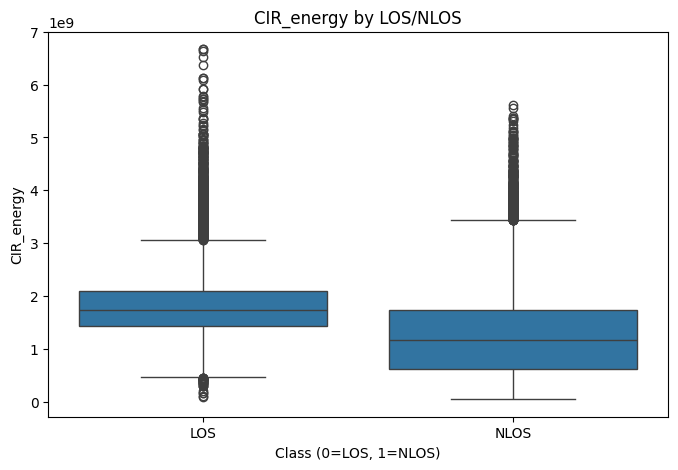

In [9]:
summary_features = ['CIR_mean', 'CIR_std', 'CIR_max', 'CIR_energy']

for feature in summary_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.xlabel('Class (0=LOS, 1=NLOS)')
    plt.ylabel(feature)
    plt.xticks([0, 1], ['LOS', 'NLOS'])
    plt.show()

## Visualisations for all other features non-CIR cols

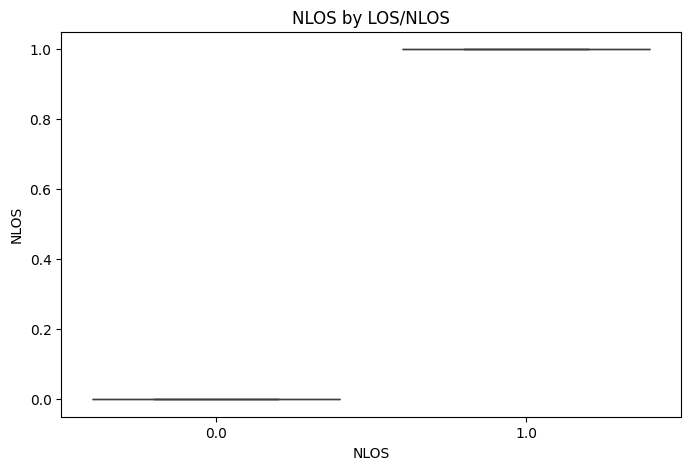

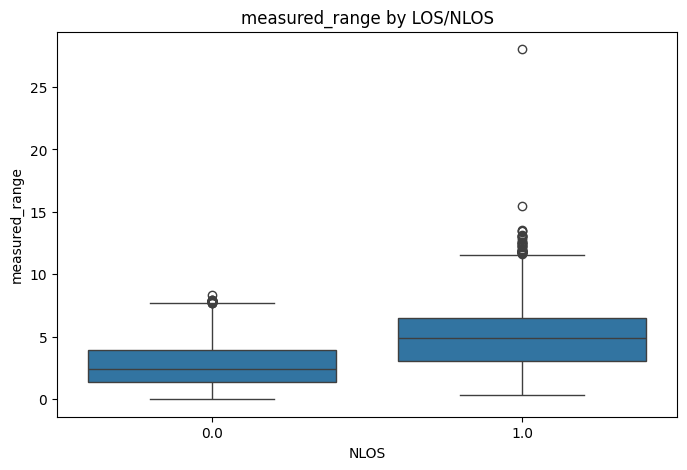

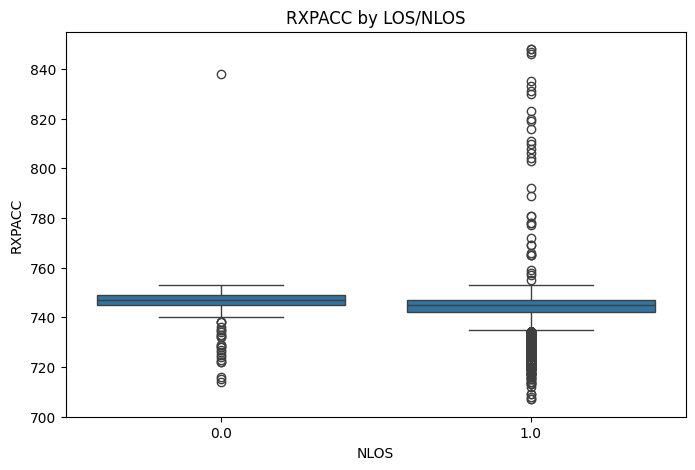

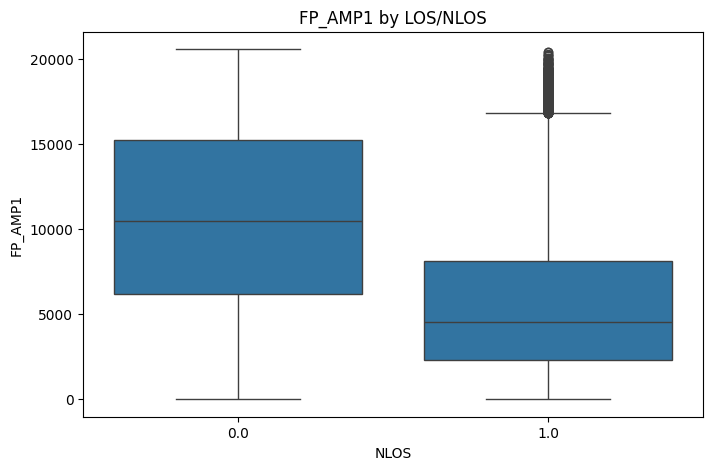

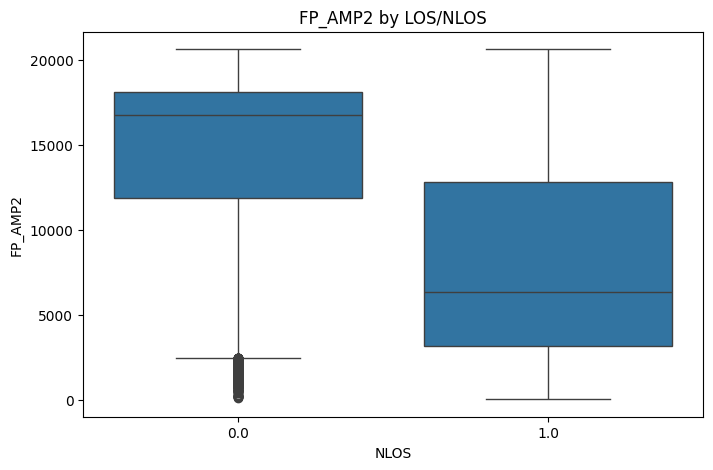

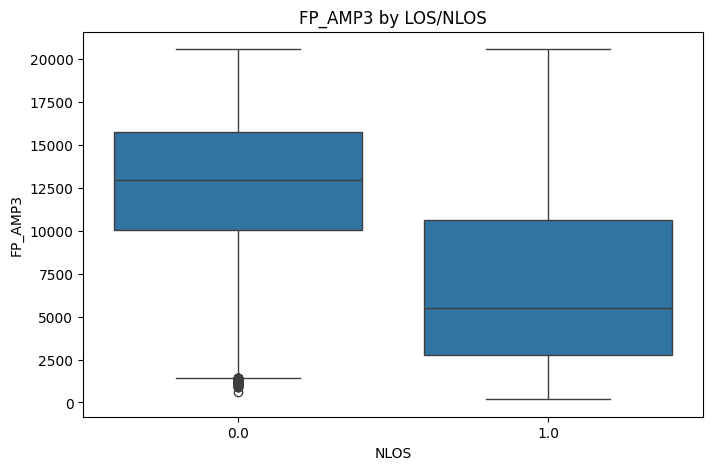

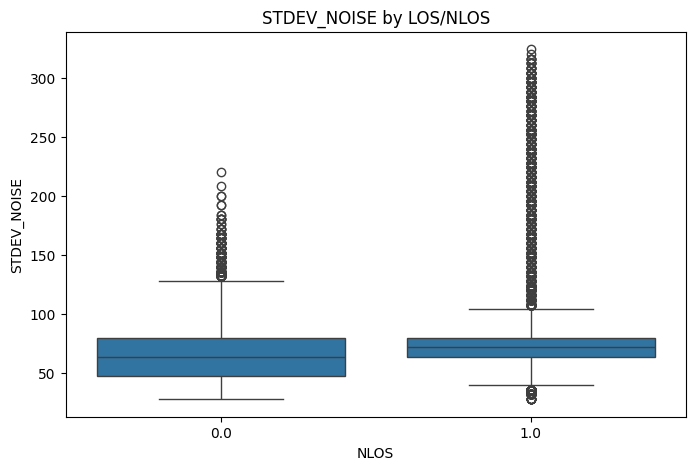

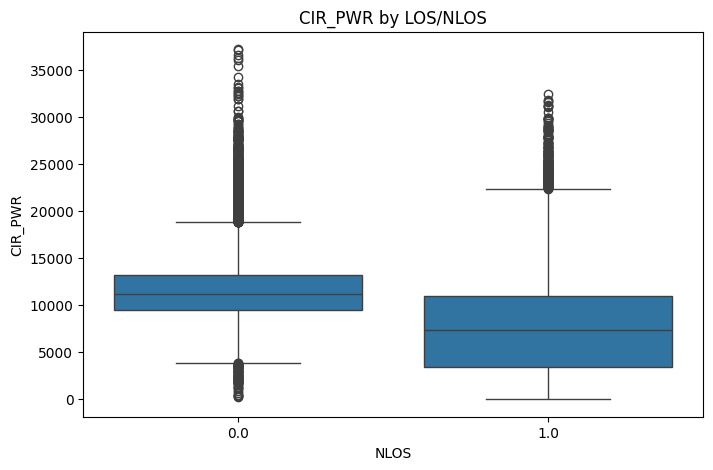

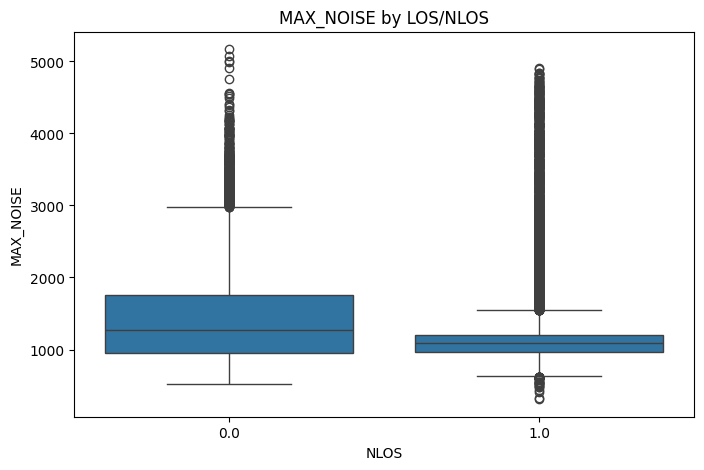

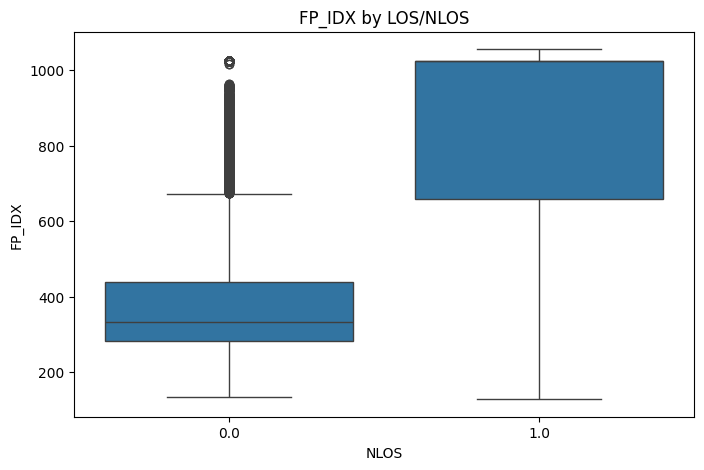

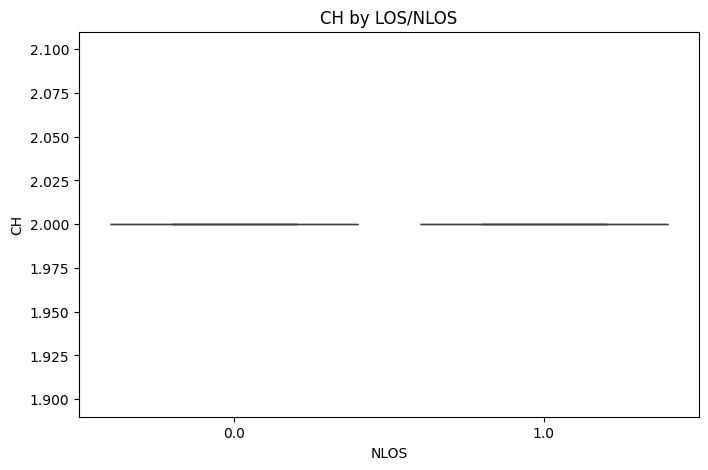

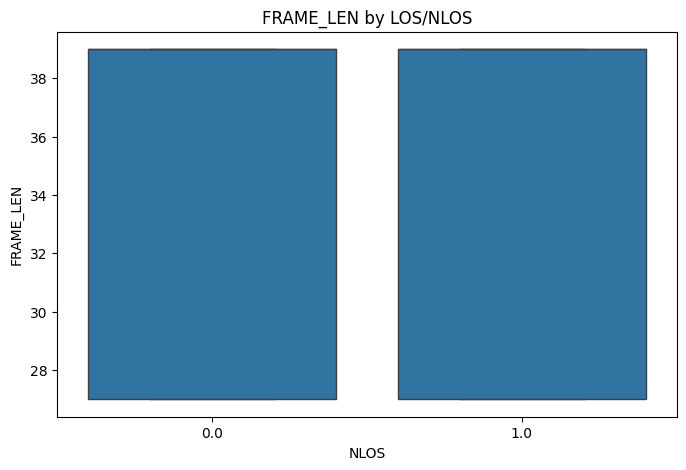

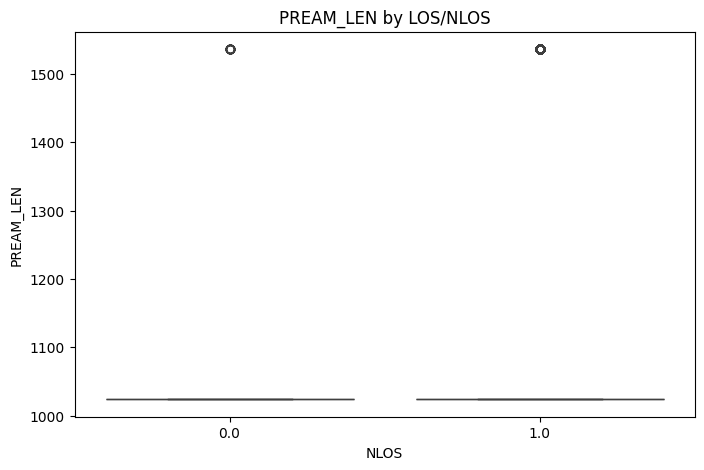

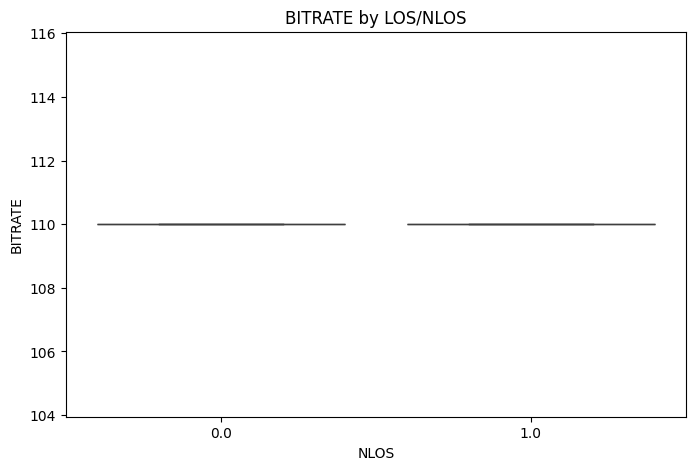

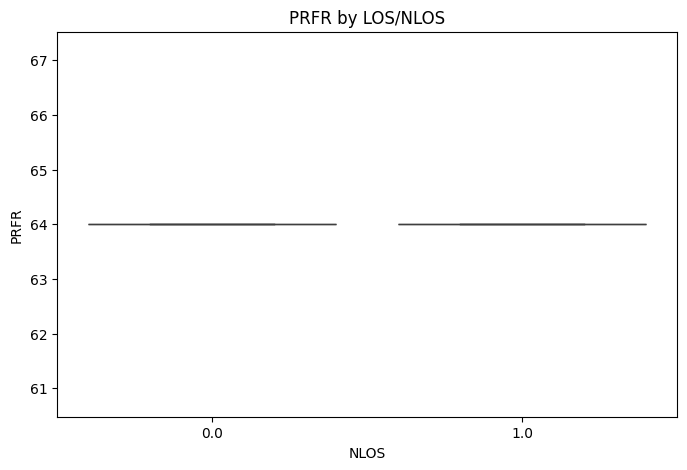

In [10]:
# other_features = ['measured_range', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
#                   'FP_IDX', 'STDEV_NOISE', 'CIR_PWR']

for feature in main_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.show()


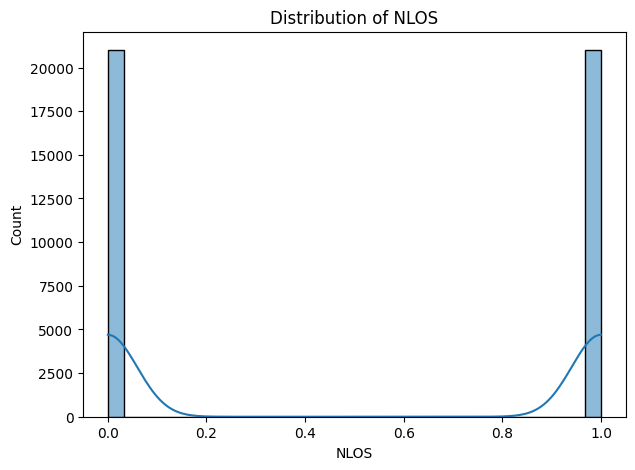

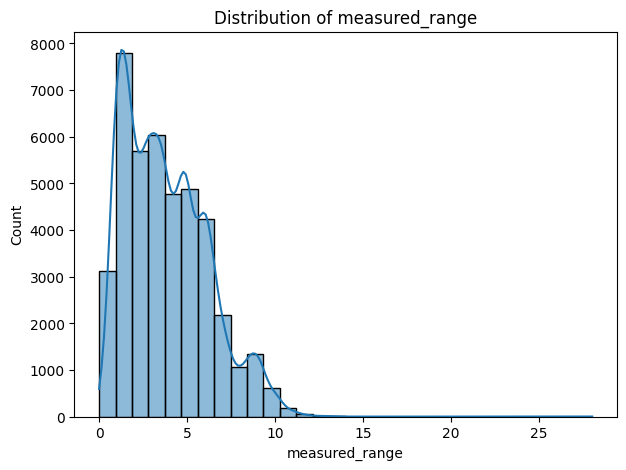

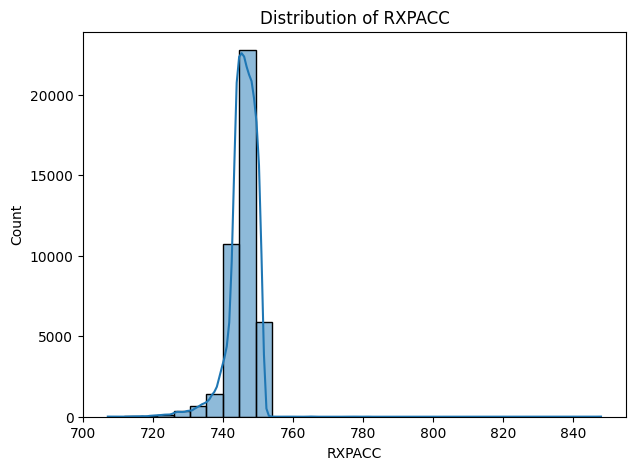

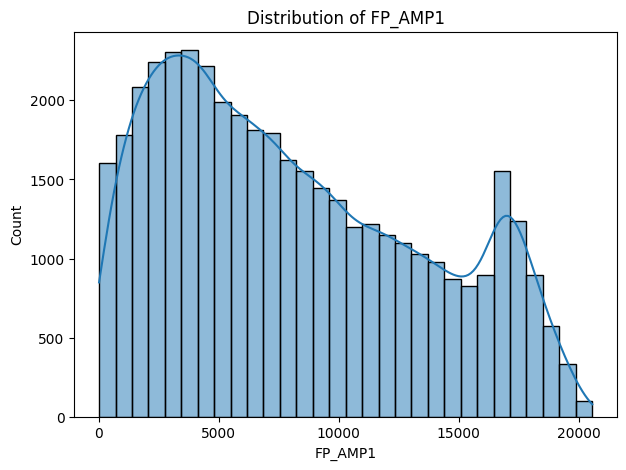

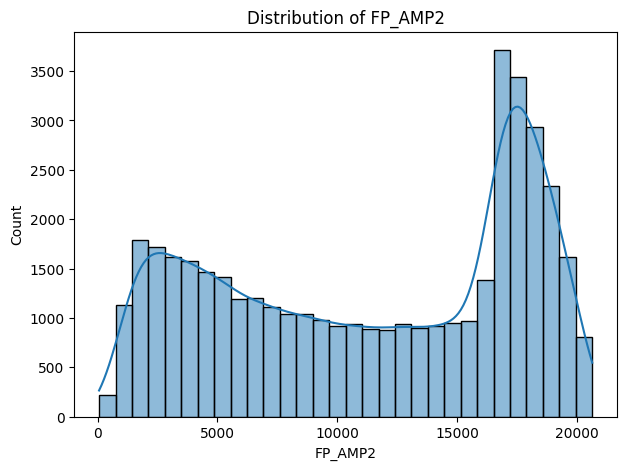

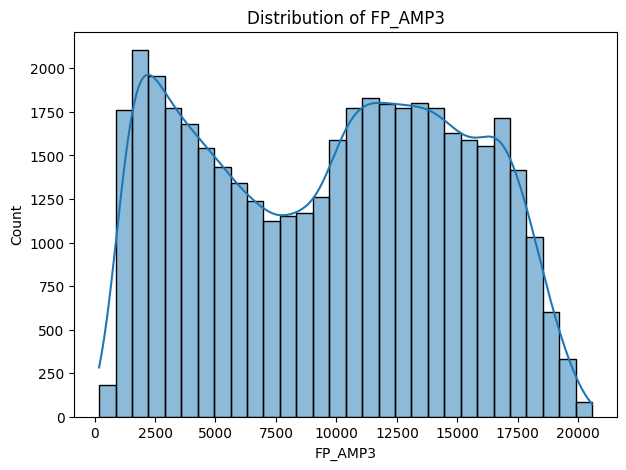

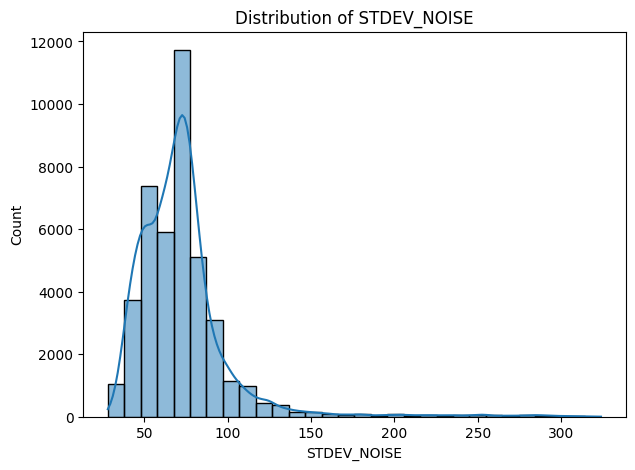

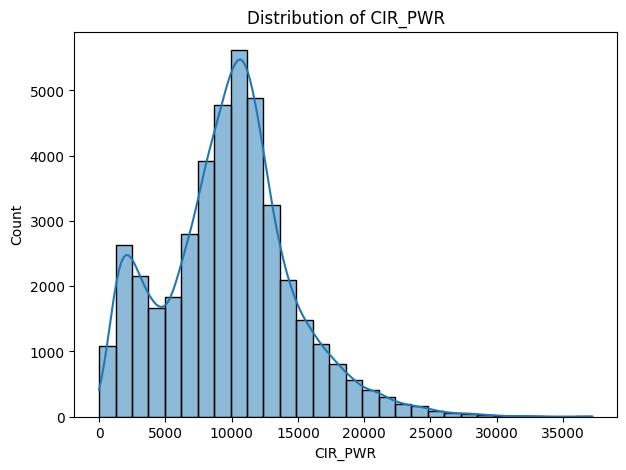

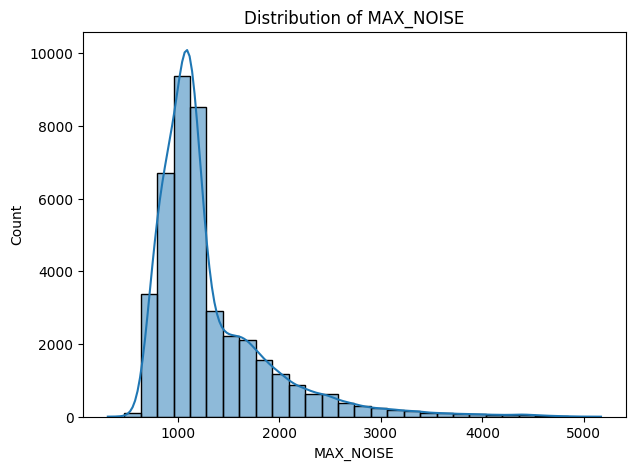

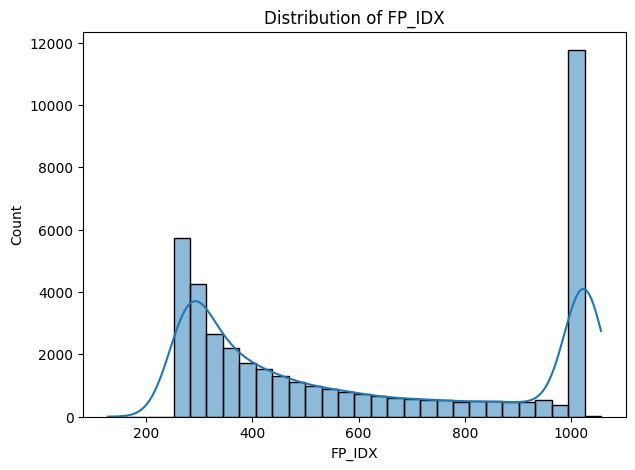

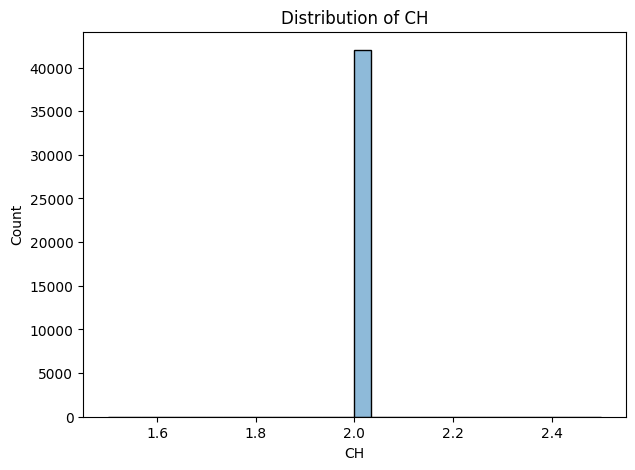

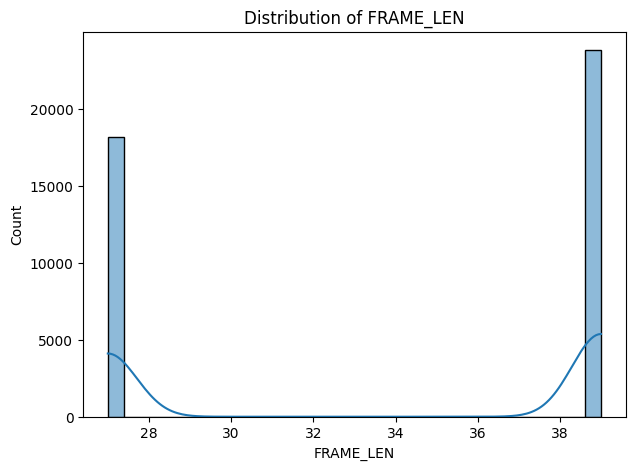

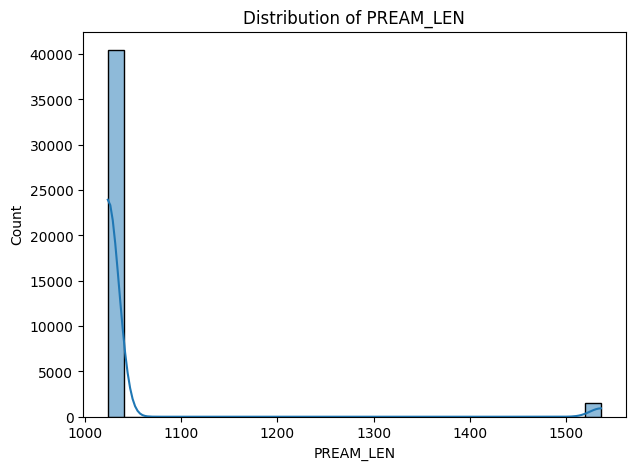

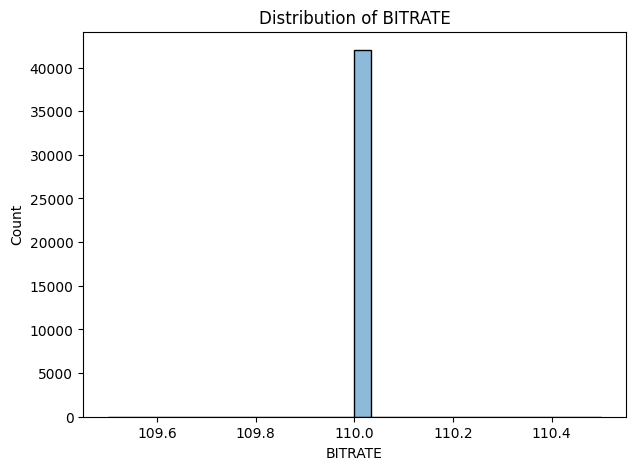

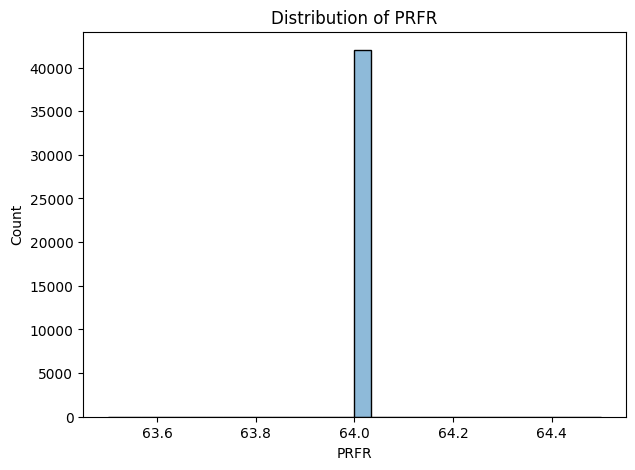

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in main_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()


In [12]:
variance = df[main_features].var()
print("Variance for each non-CIR attribute")
print(variance)

Variance for each non-CIR attribute
NLOS              2.500060e-01
measured_range    5.550622e+00
RXPACC            2.029524e+01
FP_AMP1           2.908802e+07
FP_AMP2           3.888065e+07
FP_AMP3           2.864724e+07
STDEV_NOISE       8.596035e+02
CIR_PWR           2.413321e+07
MAX_NOISE         3.392305e+05
FP_IDX            9.411726e+04
CH                0.000000e+00
FRAME_LEN         3.535754e+01
PREAM_LEN         9.358013e+03
BITRATE           0.000000e+00
PRFR              0.000000e+00
dtype: float64


<font color='yellow'>**FINDINGS**</font>
>from this graphs you can tell there are 4 attributes that have constant values regardless of NLOS/LOS; thus most likely uninsightful and can be dropped but let's confirm it with more statistical evidence. The 4 attributes include 
> - CH 
> - BITRATE 
> - PRFR
> - PREAM_LEN
>
>
>  *High Variance*
>   - Captures more variability in data 
>   - More insightful in finding out patterns or making predictions
>
>
> However looking at the variance table you can tell it has a high variance compared to 0/negligible values for the other 3. Thus we will keep PREAM_LEN but remove the other 3 columns

## Data Cleaning

### Removing less important features

In [13]:
# Create a copy of the original DataFrame
df_original = df.copy()

# Define the columns to drop
drop_cols = ['CH', 'BITRATE', 'PRFR']

# Drop the specified columns from the DataFrame
df = df.drop(columns=drop_cols)

# Print the shape of the original and updated DataFrames
print(f"Copy of original df shape: {df_original.shape}")
print(f"Updated dropped shape: {df.shape}")

# Display the column names of the original and updated DataFrames
print("Original DataFrame columns:")
print(df_original.columns.tolist())
print("\nUpdated DataFrame columns:")
print(df.columns.tolist())

Copy of original df shape: (42000, 1035)
Updated dropped shape: (42000, 1032)
Original DataFrame columns:
['NLOS', 'measured_range', 'RXPACC', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'FP_IDX', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR_0', 'CIR_1', 'CIR_2', 'CIR_3', 'CIR_4', 'CIR_5', 'CIR_6', 'CIR_7', 'CIR_8', 'CIR_9', 'CIR_10', 'CIR_11', 'CIR_12', 'CIR_13', 'CIR_14', 'CIR_15', 'CIR_16', 'CIR_17', 'CIR_18', 'CIR_19', 'CIR_20', 'CIR_21', 'CIR_22', 'CIR_23', 'CIR_24', 'CIR_25', 'CIR_26', 'CIR_27', 'CIR_28', 'CIR_29', 'CIR_30', 'CIR_31', 'CIR_32', 'CIR_33', 'CIR_34', 'CIR_35', 'CIR_36', 'CIR_37', 'CIR_38', 'CIR_39', 'CIR_40', 'CIR_41', 'CIR_42', 'CIR_43', 'CIR_44', 'CIR_45', 'CIR_46', 'CIR_47', 'CIR_48', 'CIR_49', 'CIR_50', 'CIR_51', 'CIR_52', 'CIR_53', 'CIR_54', 'CIR_55', 'CIR_56', 'CIR_57', 'CIR_58', 'CIR_59', 'CIR_60', 'CIR_61', 'CIR_62', 'CIR_63', 'CIR_64', 'CIR_65', 'CIR_66', 'CIR_67', 'CIR_68', 'CIR_69', 'CIR_70', 'CIR_71', 'CIR_72', 'CIR

### Missing Values

In [14]:
# check that the categorical data for part 1 is has no other values other than 0/1
print('unique labels in NLOS: ', df['NLOS'].unique())

unique labels in NLOS:  [0. 1.]


In [15]:
# check ensure no missing values within the dataset
print('Number of instances = %d' % (df.shape[0]))
print('Number of attributes = %d' % (df.shape[1]))

print('Number of missing values:')
for col in df.columns:
    print('\t%s: %d' % (col, df[col].isna().sum()))   

Number of instances = 42000
Number of attributes = 1032
Number of missing values:
	NLOS: 0
	measured_range: 0
	RXPACC: 0
	FP_AMP1: 0
	FP_AMP2: 0
	FP_AMP3: 0
	STDEV_NOISE: 0
	CIR_PWR: 0
	MAX_NOISE: 0
	FP_IDX: 0
	FRAME_LEN: 0
	PREAM_LEN: 0
	CIR_0: 0
	CIR_1: 0
	CIR_2: 0
	CIR_3: 0
	CIR_4: 0
	CIR_5: 0
	CIR_6: 0
	CIR_7: 0
	CIR_8: 0
	CIR_9: 0
	CIR_10: 0
	CIR_11: 0
	CIR_12: 0
	CIR_13: 0
	CIR_14: 0
	CIR_15: 0
	CIR_16: 0
	CIR_17: 0
	CIR_18: 0
	CIR_19: 0
	CIR_20: 0
	CIR_21: 0
	CIR_22: 0
	CIR_23: 0
	CIR_24: 0
	CIR_25: 0
	CIR_26: 0
	CIR_27: 0
	CIR_28: 0
	CIR_29: 0
	CIR_30: 0
	CIR_31: 0
	CIR_32: 0
	CIR_33: 0
	CIR_34: 0
	CIR_35: 0
	CIR_36: 0
	CIR_37: 0
	CIR_38: 0
	CIR_39: 0
	CIR_40: 0
	CIR_41: 0
	CIR_42: 0
	CIR_43: 0
	CIR_44: 0
	CIR_45: 0
	CIR_46: 0
	CIR_47: 0
	CIR_48: 0
	CIR_49: 0
	CIR_50: 0
	CIR_51: 0
	CIR_52: 0
	CIR_53: 0
	CIR_54: 0
	CIR_55: 0
	CIR_56: 0
	CIR_57: 0
	CIR_58: 0
	CIR_59: 0
	CIR_60: 0
	CIR_61: 0
	CIR_62: 0
	CIR_63: 0
	CIR_64: 0
	CIR_65: 0
	CIR_66: 0
	CIR_67: 0
	CIR_68: 0
	CIR_69: 0
	C

### different dtype rom what is expected

In [16]:
#check if the values have anything other than numeric float64 basically
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Unique values in {col}: {unique_values[:10]}")  # Show first 10 unique values


Unique values in NLOS: [0. 1.]
Unique values in measured_range: [3.9  0.66 7.86 3.48 1.19 1.27 0.28 1.23 4.99 1.17]
Unique values in RXPACC: [745. 749. 746. 750. 748. 744. 747. 737. 741. 751.]
Unique values in FP_AMP1: [18712. 11239.  4355.  8502. 17845.  3446. 18991. 14781.  4053. 10153.]
Unique values in FP_AMP2: [10250.  6313.  5240.  8416. 18095. 13680. 19444. 10399.  8174.  7675.]
Unique values in FP_AMP3: [11576.  4712.  3478.  5890. 12058. 11955. 18370. 10136.  5404.  6064.]
Unique values in STDEV_NOISE: [ 64.  60.  76.  68.  92. 148.  40. 100. 108.  44.]
Unique values in CIR_PWR: [11855. 18968. 14699.  8748. 11380. 10256. 13006.  8025.  9956. 11466.]
Unique values in MAX_NOISE: [ 967. 1133.  894. 1127. 1744. 1397. 3904. 1035. 1485. 2487.]
Unique values in FP_IDX: [ 611.  447.  723. 1024.  276.  600.  283.  272.  301.  278.]
Unique values in FRAME_LEN: [39. 27. 29.]
Unique values in PREAM_LEN: [1024. 1536.]
Unique values in CIR_0: [129. 117. 433. 466. 259. 465. 284. 191. 207.  6

### check for dups

In [17]:
dups = df.duplicated()
dups

0        False
1        False
2        False
3        False
4        False
         ...  
41995    False
41996    False
41997    False
41998    False
41999    False
Length: 42000, dtype: bool

In [18]:
duplicate = df[df.duplicated()]
duplicate

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015,CIR_mean,CIR_std,CIR_max,CIR_energy


### checking for unequal distribution of target variable

Number of LOS samples: 21000
Number of NLOS samples: 21000


C:\Users\jiawei\AppData\Local\Temp\ipykernel_47016\159130609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=los_nlos_counts.index, y=los_nlos_counts.values, palette='coolwarm')


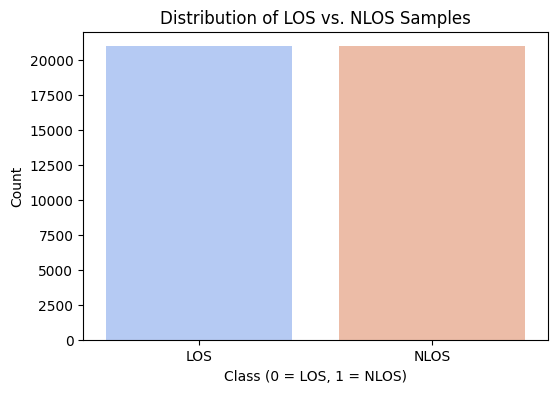

In [19]:
# Count occurrences of each class (assuming 'NLOS' is the column representing LOS/NLOS)
los_nlos_counts = df['NLOS'].value_counts()

# Print the counts
print("Number of LOS samples:", los_nlos_counts[0])  # LOS (0)
print("Number of NLOS samples:", los_nlos_counts[1])  # NLOS (1)

# Optional: Plot the class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=los_nlos_counts.index, y=los_nlos_counts.values, palette='coolwarm')
plt.xlabel("Class (0 = LOS, 1 = NLOS)")
plt.ylabel("Count")
plt.title("Distribution of LOS vs. NLOS Samples")
plt.xticks([0, 1], ["LOS", "NLOS"])
plt.show()


In [20]:
column_names = df.columns.tolist()
print("Column names:")
for name in column_names:
    print(name)

Column names:
NLOS
measured_range
RXPACC
FP_AMP1
FP_AMP2
FP_AMP3
STDEV_NOISE
CIR_PWR
MAX_NOISE
FP_IDX
FRAME_LEN
PREAM_LEN
CIR_0
CIR_1
CIR_2
CIR_3
CIR_4
CIR_5
CIR_6
CIR_7
CIR_8
CIR_9
CIR_10
CIR_11
CIR_12
CIR_13
CIR_14
CIR_15
CIR_16
CIR_17
CIR_18
CIR_19
CIR_20
CIR_21
CIR_22
CIR_23
CIR_24
CIR_25
CIR_26
CIR_27
CIR_28
CIR_29
CIR_30
CIR_31
CIR_32
CIR_33
CIR_34
CIR_35
CIR_36
CIR_37
CIR_38
CIR_39
CIR_40
CIR_41
CIR_42
CIR_43
CIR_44
CIR_45
CIR_46
CIR_47
CIR_48
CIR_49
CIR_50
CIR_51
CIR_52
CIR_53
CIR_54
CIR_55
CIR_56
CIR_57
CIR_58
CIR_59
CIR_60
CIR_61
CIR_62
CIR_63
CIR_64
CIR_65
CIR_66
CIR_67
CIR_68
CIR_69
CIR_70
CIR_71
CIR_72
CIR_73
CIR_74
CIR_75
CIR_76
CIR_77
CIR_78
CIR_79
CIR_80
CIR_81
CIR_82
CIR_83
CIR_84
CIR_85
CIR_86
CIR_87
CIR_88
CIR_89
CIR_90
CIR_91
CIR_92
CIR_93
CIR_94
CIR_95
CIR_96
CIR_97
CIR_98
CIR_99
CIR_100
CIR_101
CIR_102
CIR_103
CIR_104
CIR_105
CIR_106
CIR_107
CIR_108
CIR_109
CIR_110
CIR_111
CIR_112
CIR_113
CIR_114
CIR_115
CIR_116
CIR_117
CIR_118
CIR_119
CIR_120
CIR_121
CIR_122
CIR_

In [21]:
from scipy.stats import zscore

# Define features to check for outliers (Exclude CIR)
outlier_features = ['measured_range', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE']

# Compute Z-score
z_scores = df[outlier_features].apply(zscore)

# Keep only rows where all values are within 3 standard deviations
df_cleaned = df[(z_scores > -3).all(axis=1) & (z_scores <= 3).all(axis=1)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")

Original dataset shape: (42000, 1032)
Dataset shape after outlier removal: (40473, 1032)


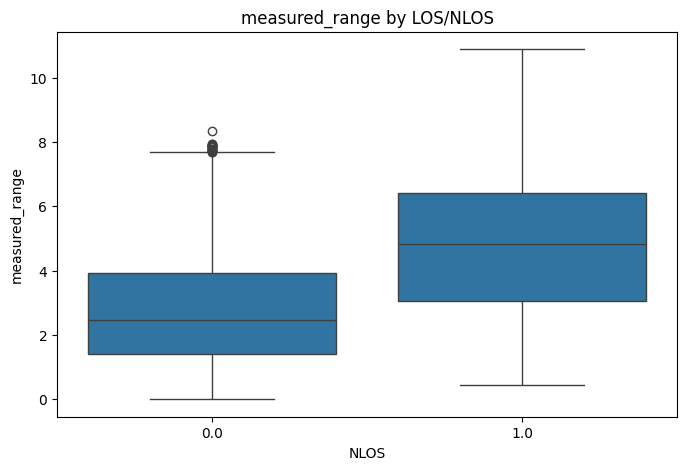

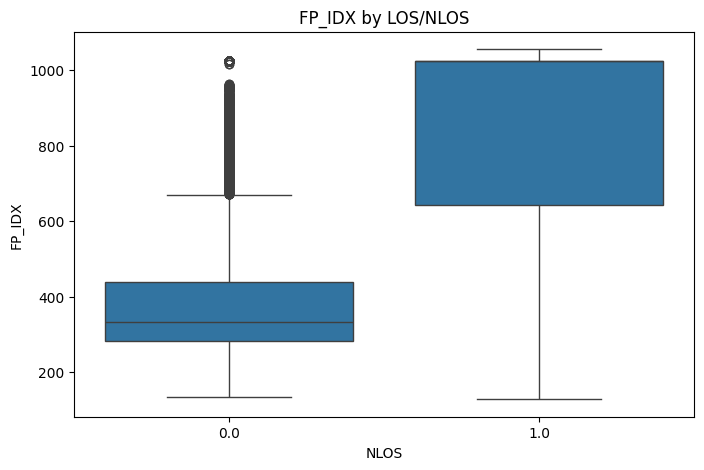

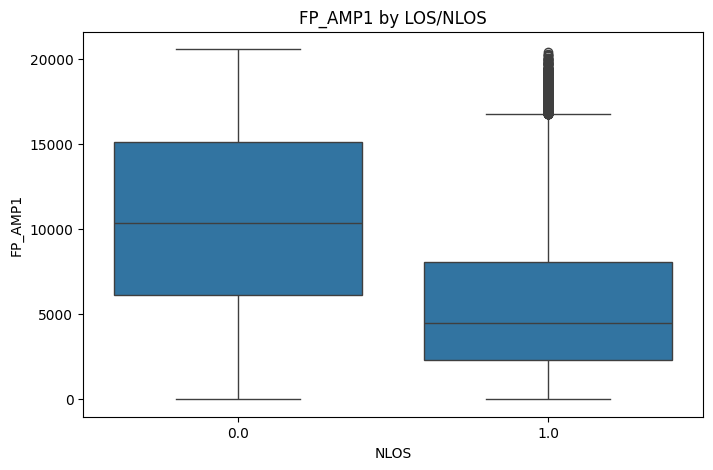

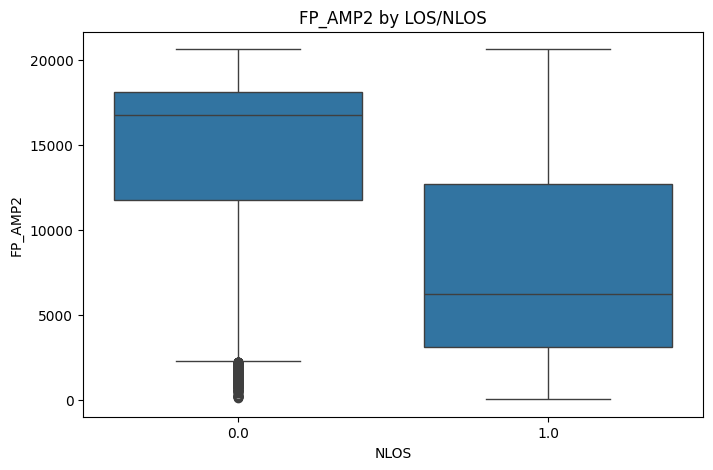

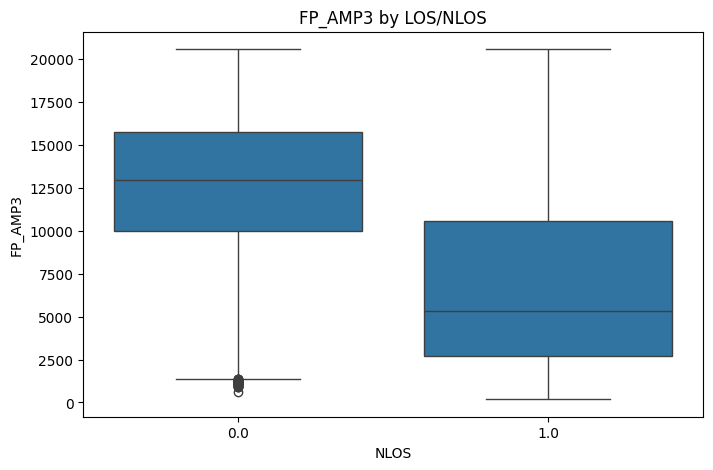

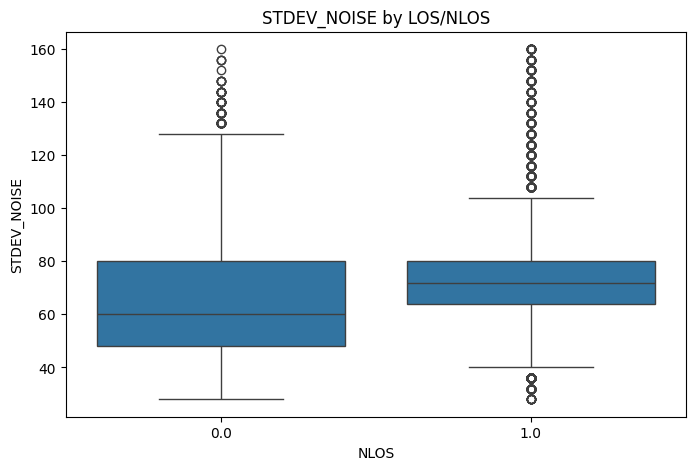

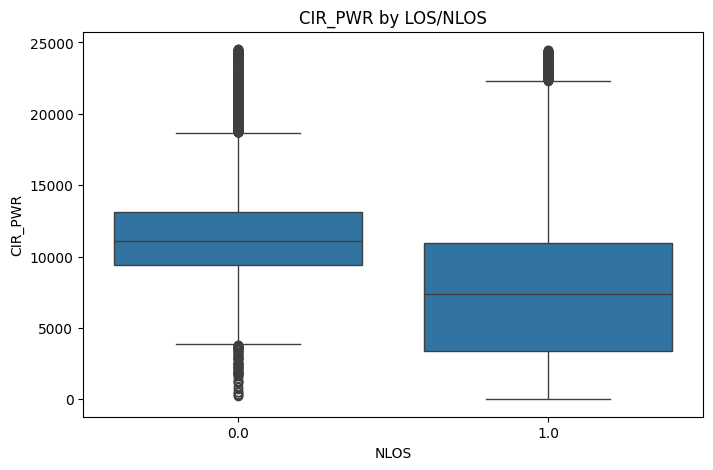

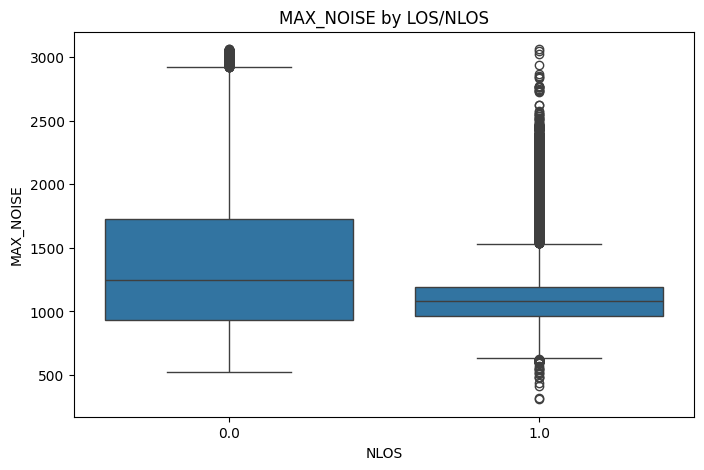

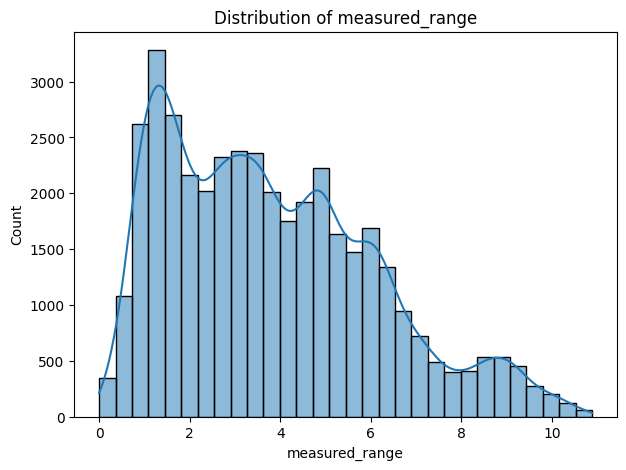

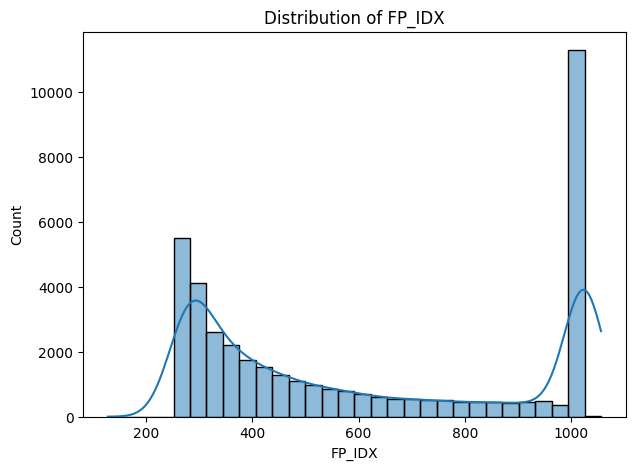

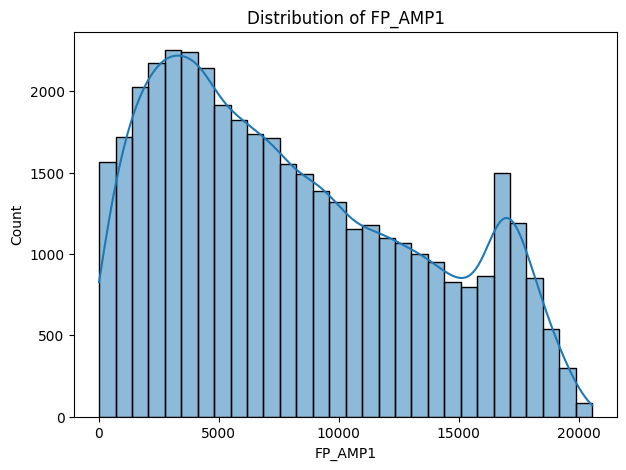

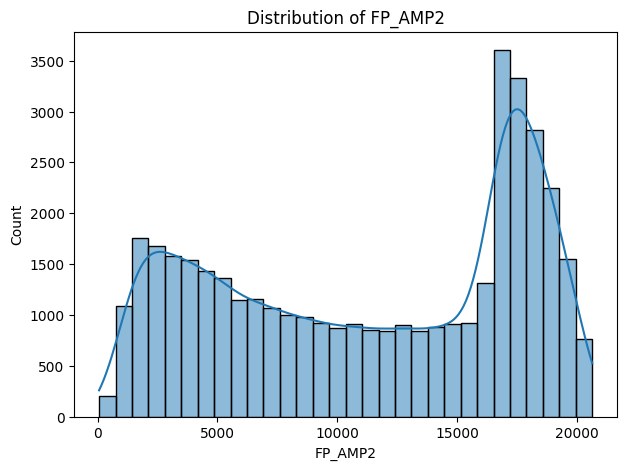

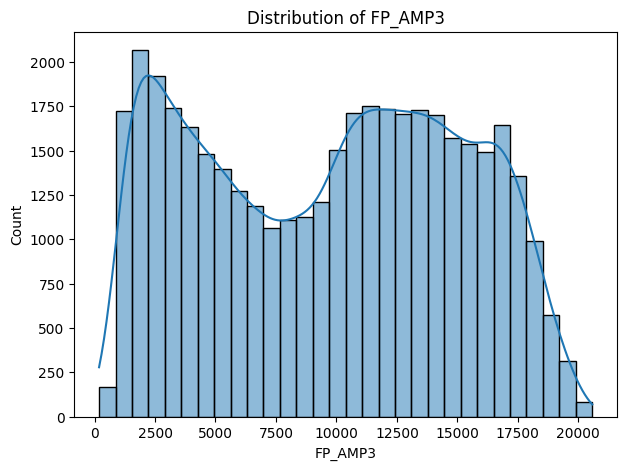

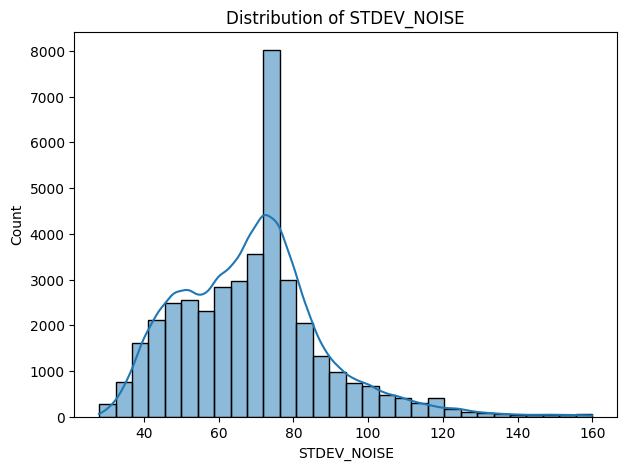

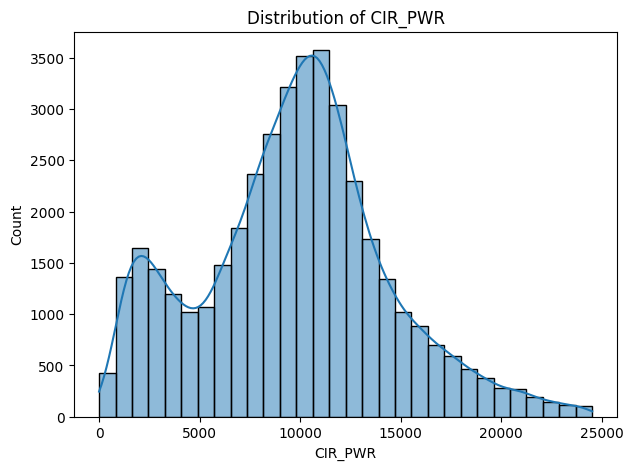

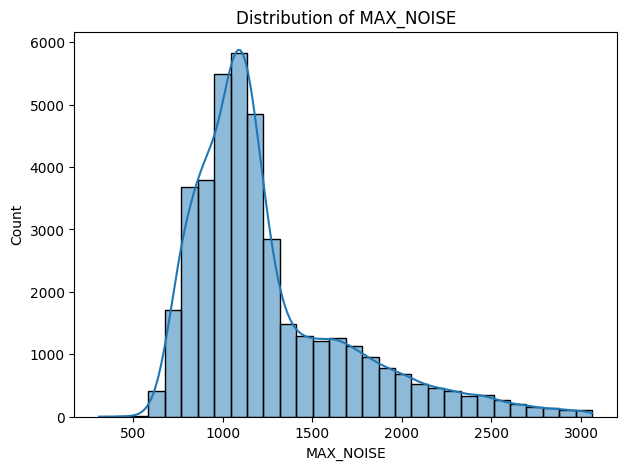

In [22]:
for feature in outlier_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_cleaned, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

for feature in outlier_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df_cleaned[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()



## VIF Scores (Not gonna use most likely)

In [23]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Compute VIF for all features (excluding CIR columns)
# X = df_cleaned[outlier_features]  
# vif_data = pd.DataFrame()
# vif_data["Feature"] = X.columns
# vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# print("VIF Scores:")
# print(vif_data.sort_values(by="VIF", ascending=False))

# # Drop highly correlated features (VIF > 5)
# high_vif_features = vif_data[vif_data["VIF"] > 5]["Feature"].tolist()
# df_vif_reduced = df_cleaned.drop(columns=high_vif_features)

# print(f"Remaining features after VIF filtering: {df_vif_reduced.shape[1]}")


## Fast Fournier Transfrom (FFT)

Formula:


$T_f = \mu \cdot N \cdot r$


Where:
- \( T_f \) is the frictional torque
- \( \mu \) is the coefficient of friction
- \( N \) is the normal force
- \( r \) is the radius at which the force is applied






In [24]:
df_cleaned.shape

(40473, 1032)

In [25]:
df_cleaned.head()

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015,CIR_mean,CIR_std,CIR_max,CIR_energy
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,198.0,87.0,296.0,505.0,307.0,0.0,406.493609,1277.261626,23077.0,1.825546e+09
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,187.0,213.0,202.0,89.0,103.0,0.0,462.274336,1731.995119,18968.0,3.265134e+09
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,124.0,329.0,207.0,96.0,218.0,0.0,517.443461,1433.695551,16809.0,2.360670e+09
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,434.0,397.0,290.0,155.0,342.0,256.0,421.249754,1079.099721,15742.0,1.363556e+09
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,87.0,178.0,314.0,247.0,292.0,256.0,374.189774,1247.746056,19583.0,1.724178e+09


In [26]:
# Make a copy of the cleaned dataframe
df_fft = df_cleaned.copy()

# Identify CIR columns (1016 columns)
cir_columns = [col for col in df_fft.columns if 'CIR_' in col and col not in ['CIR_PWR', 'CIR_mean', 'CIR_max', 'CIR_std', 'CIR_energy']]

# Ensure CIR columns exist
if not cir_columns:
    raise ValueError("No CIR columns found!")

# Compute FFT for each row, keeping only 1016 CIR values
fft_values = df_fft[cir_columns].apply(lambda row: np.abs(fft(row.to_numpy())), axis=1)

# Create FFT column names
fft_columns = [f'FFT_{i}' for i in range(len(cir_columns))]  # 1016 FFT columns

# Convert FFT values into DataFrame
fft_df = pd.DataFrame(fft_values.tolist(), columns=fft_columns, index=df_fft.index)

# Concatenate FFT features while keeping the original dataset (except CIR columns)
df_fft = pd.concat([df_fft.drop(columns=cir_columns), fft_df], axis=1)

print(f"Dataset shape after replacing CIR with FFT features: {df_fft.shape}")

Dataset shape after replacing CIR with FFT features: (40473, 1032)


In [27]:
df_fft.head()

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,FFT_1006,FFT_1007,FFT_1008,FFT_1009,FFT_1010,FFT_1011,FFT_1012,FFT_1013,FFT_1014,FFT_1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,147363.580386,156993.029852,157508.713787,159284.355187,164661.802783,170808.640426,169869.361433,170881.074380,172218.295753,176143.139130
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,199736.436094,205347.386528,213356.614836,217296.396829,222944.309688,232368.316737,234558.979076,242363.138758,247273.488409,248007.108944
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,160064.552114,169194.398622,175908.800760,188432.403230,198740.768169,226308.229453,238309.603004,262890.558709,277560.207867,282638.075317
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,127889.940510,131819.209398,137981.690665,137379.511692,138569.940418,145046.920891,148356.463666,144111.339108,152201.642761,143584.438466
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,114351.866172,117578.777597,124726.508044,128587.200245,126080.397723,128417.188951,130807.229975,140699.927983,145627.201594,149284.240427


In [28]:
# Ensure CIR columns exist
fft_columns = [col for col in df_fft.columns if 'FFT_' in col]
if not fft_columns:
    fft_columns = [f'CIR_{i}' for i in range(1016)]  # Ensure correct column names
    df_fft[fft_columns] = df_cleaned[fft_columns]  # Restore if missing

# Compute FFT features safely
df_fft['FFT_energy'] = df_fft[fft_columns].apply(lambda row: np.sum(np.abs(fft(row.to_numpy()))**2), axis=1)
df_fft['FFT_max_freq'] = df_fft[fft_columns].apply(lambda row: np.argmax(np.abs(fft(row.to_numpy()))), axis=1)
df_fft['FFT_mean'] = df_fft[fft_columns].apply(lambda row: np.mean(np.abs(fft(row.to_numpy()))), axis=1)
df_fft['FFT_std'] = df_fft[fft_columns].apply(lambda row: np.std(np.abs(fft(row.to_numpy()))), axis=1)

print(f"Dataset shape after extracting FFT features: {df_fft.shape}")


Dataset shape after extracting FFT features: (40473, 1036)


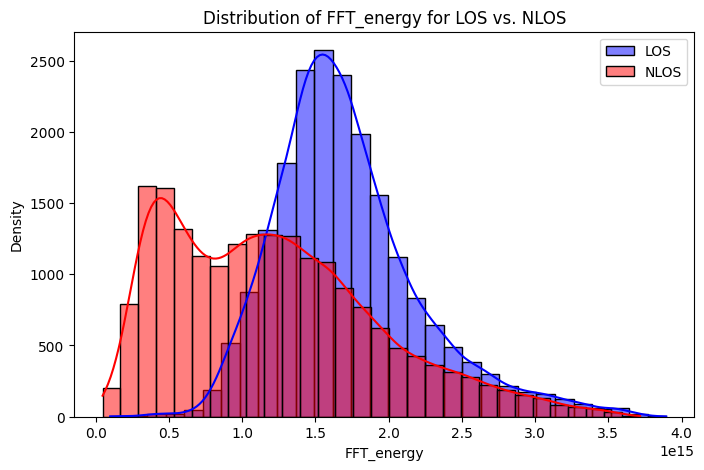

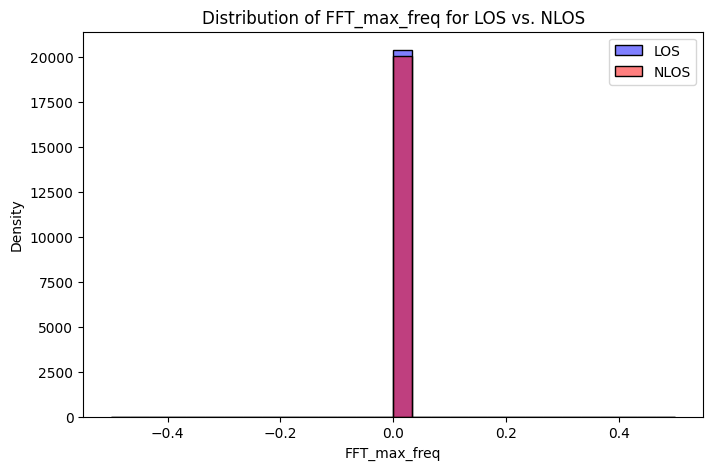

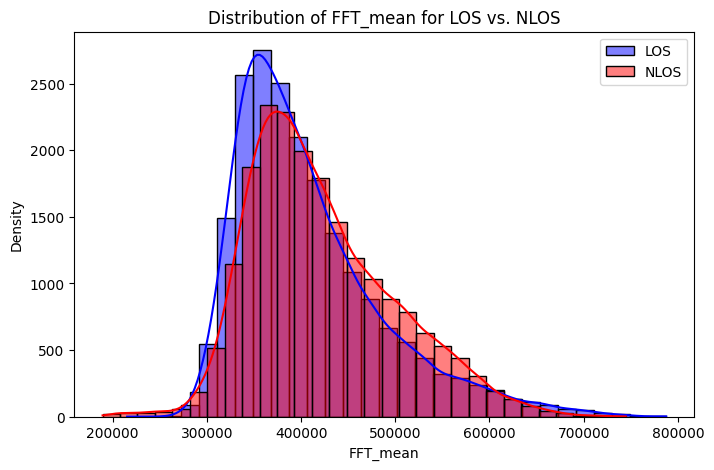

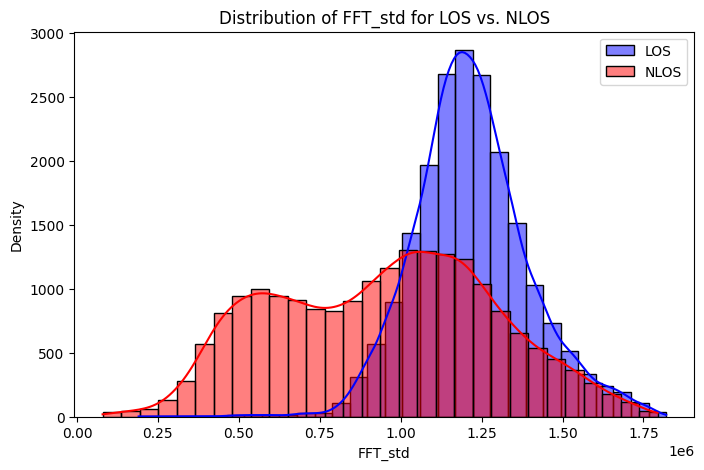

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregated FFT features to visualize
fft_aggregated_features = ['FFT_energy', 'FFT_max_freq', 'FFT_mean', 'FFT_std']

# Plot histograms for each aggregated FFT feature
for feature in fft_aggregated_features:
    plt.figure(figsize=(8,5))
    sns.histplot(df_fft[df_fft['NLOS'] == 0][feature], kde=True, color='blue', label='LOS', bins=30)
    sns.histplot(df_fft[df_fft['NLOS'] == 1][feature], kde=True, color='red', label='NLOS', bins=30)
    plt.legend()
    plt.title(f"Distribution of {feature} for LOS vs. NLOS")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.show()




## Base Model 

In [30]:
# Step 1: Split data
X = df_fft.drop(columns=['NLOS'])
y = df_fft['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Define base models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'MLP (Neural Net)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
}

# Step 3: Train & evaluate
results = []
    
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

# Step 4: Results Table
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

# Step 5: Visualization (Side-by-side bar plot)
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

KeyboardInterrupt: 

In [ ]:
# %pip install xgboost
# XGBoost Implementation
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
# Step 1: Split data
X = df_fft.drop(columns=['NLOS'])
y = df_fft['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# # Prepare data
# X = df_fft.drop(columns=['NLOS'])
# y = df_final['NLOS']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost Model
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred_xgb))

In [ ]:
# Save the trained model
joblib.dump(xgb_clf, "model-checkpoint/xgboost_base_model.pkl")
print("Model saved successfully!")

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, MaxPooling1D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Tabular (non-FFT) features
non_fft_columns = [col for col in df_fft.columns if col not in fft_columns + ['NLOS']]
X_tabular = df_fft[non_fft_columns].values

# Signal (FFT) features
X_signal = df_fft[fft_columns].values.reshape(-1, len(fft_columns), 1)
y = to_categorical(df_fft['NLOS'].values)

# Split both inputs
tab_X_train, tab_X_test, sig_X_train, sig_X_test, y_train, y_test = train_test_split(
    X_tabular, X_signal, y, test_size=0.2, random_state=42, stratify=df_fft['NLOS'])

# --- CNN branch ---
signal_input = Input(shape=(len(fft_columns), 1))
x = Conv1D(32, kernel_size=5, activation='relu')(signal_input)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(64, kernel_size=3, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Flatten()(x)

# --- Dense branch ---
tabular_input = Input(shape=(X_tabular.shape[1],))
y_tab = Dense(32, activation='relu')(tabular_input)

# --- Merge both branches ---
merged = Concatenate()([x, y_tab])
out = Dense(64, activation='relu')(merged)
out = Dense(2, activation='softmax')(out)

# Compile model
model = Model(inputs=[signal_input, tabular_input], outputs=out)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit([sig_X_train, tab_X_train], y_train, epochs=40, batch_size=32, validation_data=([sig_X_test, tab_X_test], y_test))

# Evaluate
loss, acc = model.evaluate([sig_X_test, tab_X_test], y_test)
print("Hybrid CNN + Dense Accuracy Score:", acc)


Epoch 1/40


c:\Users\jiawei\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_6']. Received: the structure of inputs=('*', '*')
  warnings.warn(


1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5022 - loss: 1489954144256.0000 - val_accuracy: 0.4960 - val_loss: 1099849793536.0000
Epoch 2/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4998 - loss: 428358467584.0000 - val_accuracy: 0.4960 - val_loss: 32866187264.0000
Epoch 3/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5024 - loss: 201369354240.0000 - val_accuracy: 0.5040 - val_loss: 54235095040.0000
Epoch 4/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5061 - loss: 81779023872.0000 - val_accuracy: 0.5040 - val_loss: 58614411264.0000
Epoch 5/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5086 - loss: 49443762176.0000 - val_accuracy: 0.4960 - val_loss: 38995353600.0000
Epoch 6/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5077 - loss: 27395160064.0000 - val_accuracy: 0.4960 - val_loss: 19459522560.0000
Epoch 7/40
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5158 - loss: 20014182400.0000 - val_a

## Feature Importance 

Random Forest selected 904 features (95%)


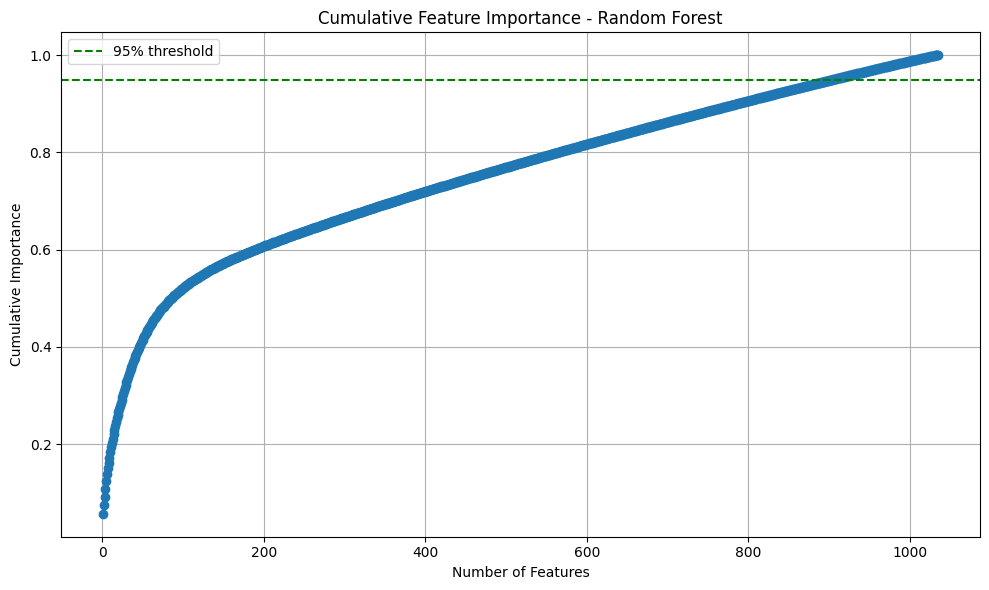

In [32]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



X = df_fft.drop(columns=['NLOS'])
y = df_fft['NLOS']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
rf_importances = rf.feature_importances_
rf_features = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)
cumulative_rf = rf_features.cumsum()

# Select top features covering 95%
rf_selected_features = rf_features[cumulative_rf <= 0.95].index
print(f"Random Forest selected {len(rf_selected_features)} features (95%)")

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_rf) + 1), cumulative_rf.values, marker='o')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance - Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# Save the trained model
joblib.dump(rf, "model-checkpoint/random_forest_base_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [34]:
# Step 1: Extract selected features from Random Forest
rflist_selected_features = list(rf_selected_features)

# Step 2: Separate FFT and non-FFT columns
rf_fft_selected = [col for col in rflist_selected_features if 'FFT_' in col]
rf_non_fft_selected = [col for col in rflist_selected_features if 'FFT_' not in col]

print(f"=== Random Forest Feature Selection ===")
print(f"Total selected features: {len(rflist_selected_features)}")
print(f"FFT selected features: {len(rf_fft_selected)}")
print(f"Non-FFT selected features: {len(rf_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", rf_fft_selected[:])
print("Non-FFT columns:\n", rf_non_fft_selected[:10])


=== Random Forest Feature Selection ===
Total selected features: 904
FFT selected features: 891
Non-FFT selected features: 13
FFT columns:
 ['FFT_32', 'FFT_33', 'FFT_31', 'FFT_39', 'FFT_976', 'FFT_982', 'FFT_30', 'FFT_956', 'FFT_974', 'FFT_41', 'FFT_34', 'FFT_960', 'FFT_35', 'FFT_979', 'FFT_38', 'FFT_985', 'FFT_37', 'FFT_975', 'FFT_49', 'FFT_983', 'FFT_27', 'FFT_973', 'FFT_24', 'FFT_43', 'FFT_991', 'FFT_980', 'FFT_972', 'FFT_53', 'FFT_977', 'FFT_986', 'FFT_988', 'FFT_961', 'FFT_29', 'FFT_mean', 'FFT_984', 'FFT_42', 'FFT_21', 'FFT_0', 'FFT_978', 'FFT_995', 'FFT_981', 'FFT_964', 'FFT_48', 'FFT_994', 'FFT_45', 'FFT_993', 'FFT_998', 'FFT_959', 'FFT_60', 'FFT_std', 'FFT_57', 'FFT_963', 'FFT_957', 'FFT_28', 'FFT_74', 'FFT_55', 'FFT_508', 'FFT_50', 'FFT_58', 'FFT_1014', 'FFT_61', 'FFT_54', 'FFT_954', 'FFT_962', 'FFT_1013', 'FFT_47', 'FFT_989', 'FFT_2', 'FFT_63', 'FFT_4', 'FFT_955', 'FFT_56', 'FFT_26', 'FFT_1012', 'FFT_969', 'FFT_381', 'FFT_3', 'FFT_5', 'FFT_1015', 'FFT_energy', 'FFT_64', 'FFT

XGBoost selected 463 features (95%)


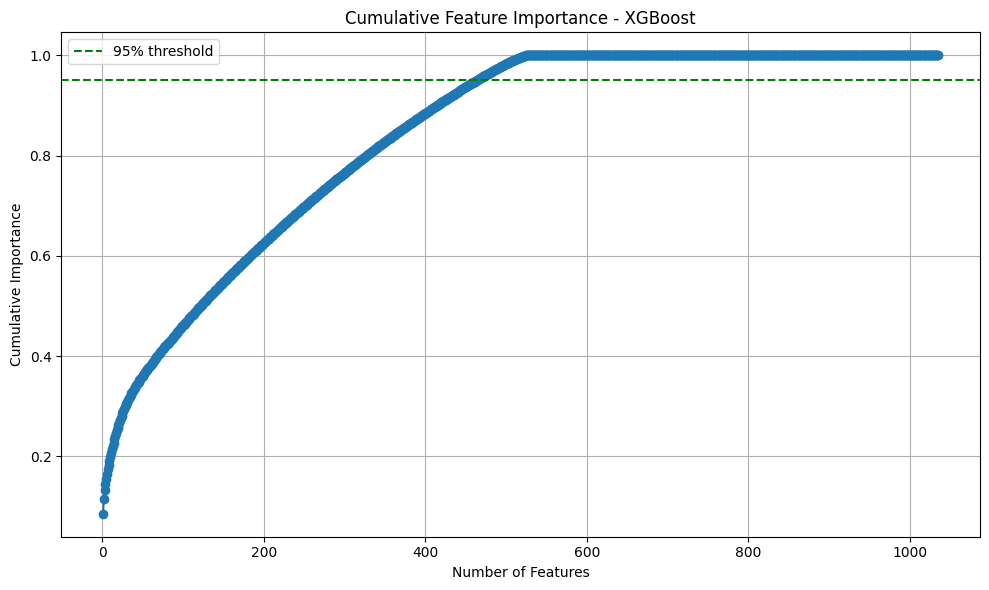

In [35]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_clf.fit(X, y)

xgb_importances = xgb_clf.feature_importances_
xgb_features = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
cumulative_xgb = xgb_features.cumsum()

xgb_selected_features = xgb_features[cumulative_xgb <= 0.95].index
print(f"XGBoost selected {len(xgb_selected_features)} features (95%)")

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_xgb) + 1), cumulative_xgb.values, marker='o')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance - XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
# Save the trained model
joblib.dump(xgb_clf, "model-checkpoint/xgboost_base_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [37]:
# Step 1: Extract selected features from Random Forest
xgblist_selected_features = list(xgb_selected_features)

# Step 2: Separate FFT and non-FFT columns
xgb_fft_selected = [col for col in xgblist_selected_features if 'FFT_' in col]
xgb_non_fft_selected = [col for col in xgblist_selected_features if 'FFT_' not in col]

print(f"=== XGBoost Feature Selection ===")
print(f"Total selected features: {len(xgblist_selected_features)}")
print(f"FFT selected features: {len(xgb_fft_selected)}")
print(f"Non-FFT selected features: {len(xgb_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", xgb_fft_selected[:])
print("Non-FFT columns:\n", xgb_non_fft_selected[:10])


=== XGBoost Feature Selection ===
Total selected features: 463
FFT selected features: 449
Non-FFT selected features: 14
FFT columns:
 ['FFT_std', 'FFT_4', 'FFT_2', 'FFT_6', 'FFT_8', 'FFT_0', 'FFT_3', 'FFT_12', 'FFT_1', 'FFT_mean', 'FFT_47', 'FFT_32', 'FFT_34', 'FFT_56', 'FFT_44', 'FFT_18', 'FFT_14', 'FFT_91', 'FFT_10', 'FFT_9', 'FFT_19', 'FFT_100', 'FFT_39', 'FFT_5', 'FFT_40', 'FFT_13', 'FFT_16', 'FFT_11', 'FFT_7', 'FFT_99', 'FFT_27', 'FFT_20', 'FFT_31', 'FFT_66', 'FFT_81', 'FFT_68', 'FFT_15', 'FFT_90', 'FFT_504', 'FFT_23', 'FFT_330', 'FFT_17', 'FFT_55', 'FFT_30', 'FFT_88', 'FFT_276', 'FFT_35', 'FFT_163', 'FFT_453', 'FFT_443', 'FFT_474', 'FFT_84', 'FFT_132', 'FFT_196', 'FFT_98', 'FFT_71', 'FFT_396', 'FFT_397', 'FFT_214', 'FFT_60', 'FFT_120', 'FFT_36', 'FFT_340', 'FFT_195', 'FFT_65', 'FFT_48', 'FFT_252', 'FFT_61', 'FFT_334', 'FFT_104', 'FFT_305', 'FFT_359', 'FFT_79', 'FFT_328', 'FFT_469', 'FFT_64', 'FFT_29', 'FFT_331', 'FFT_468', 'FFT_182', 'FFT_350', 'FFT_314', 'FFT_407', 'FFT_46', 'FF

Decision Tree selected 622 features (98%)


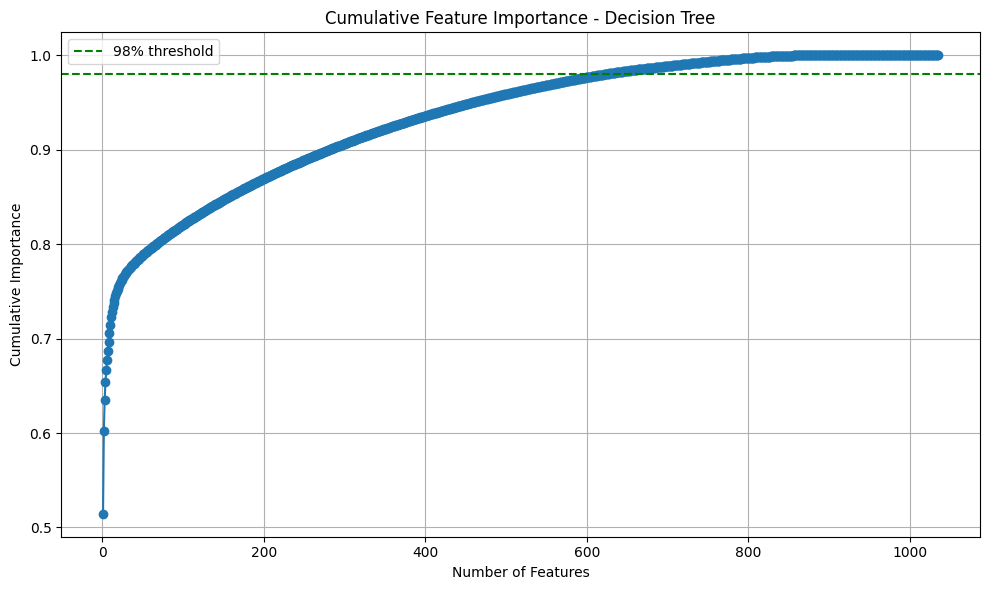

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

dt_importances = dt.feature_importances_
dt_features = pd.Series(dt_importances, index=X.columns).sort_values(ascending=False)
cumulative_dt = dt_features.cumsum()

dt_selected_features = dt_features[cumulative_dt <= 0.98].index
print(f"Decision Tree selected {len(dt_selected_features)} features (98%)")

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_dt) + 1), cumulative_dt.values, marker='o')
plt.axhline(y=0.98, color='g', linestyle='--', label='98% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance - Decision Tree')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [39]:
# Save the trained model
joblib.dump(dt, "model-checkpoint/decision_tree_base_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [40]:
# Step 1: Extract selected features from Random Forest
dtlist_selected_features = list(dt_selected_features)

# Step 2: Separate FFT and non-FFT columns
dt_fft_selected = [col for col in dtlist_selected_features if 'FFT_' in col]
dt_non_fft_selected = [col for col in dtlist_selected_features if 'FFT_' not in col]

print(f"=== Decision Tree Feature Selection ===")
print(f"Total selected features: {len(dtlist_selected_features)}")
print(f"FFT selected features: {len(dt_fft_selected)}")
print(f"Non-FFT selected features: {len(dt_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", dt_fft_selected[:])
print("Non-FFT columns:\n", dt_non_fft_selected[:10])


=== Decision Tree Feature Selection ===
Total selected features: 622
FFT selected features: 608
Non-FFT selected features: 14
FFT columns:
 ['FFT_2', 'FFT_1013', 'FFT_std', 'FFT_4', 'FFT_1', 'FFT_mean', 'FFT_508', 'FFT_0', 'FFT_1015', 'FFT_18', 'FFT_1011', 'FFT_1003', 'FFT_1014', 'FFT_1012', 'FFT_8', 'FFT_232', 'FFT_1004', 'FFT_1002', 'FFT_1000', 'FFT_40', 'FFT_568', 'FFT_37', 'FFT_16', 'FFT_783', 'FFT_807', 'FFT_751', 'FFT_12', 'FFT_159', 'FFT_103', 'FFT_29', 'FFT_14', 'FFT_220', 'FFT_6', 'FFT_450', 'FFT_979', 'FFT_611', 'FFT_980', 'FFT_26', 'FFT_635', 'FFT_198', 'FFT_981', 'FFT_35', 'FFT_193', 'FFT_763', 'FFT_788', 'FFT_499', 'FFT_534', 'FFT_678', 'FFT_506', 'FFT_716', 'FFT_539', 'FFT_83', 'FFT_298', 'FFT_139', 'FFT_7', 'FFT_184', 'FFT_248', 'FFT_1006', 'FFT_356', 'FFT_252', 'FFT_472', 'FFT_799', 'FFT_34', 'FFT_480', 'FFT_894', 'FFT_928', 'FFT_514', 'FFT_493', 'FFT_632', 'FFT_468', 'FFT_181', 'FFT_943', 'FFT_85', 'FFT_312', 'FFT_557', 'FFT_769', 'FFT_11', 'FFT_947', 'FFT_420', 'FFT_5

<!-- ### <font color='red'> CHECKPOINT RUNNING HERE</font> -->

In [41]:
# from sklearn.inspection import permutation_importance
# # Split data again if needed
# X = df_fft.drop(columns=['NLOS'])
# y = df_fft['NLOS']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Train RBF SVM
# svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
# svm_rbf.fit(X_train, y_train)

# # Permutation importance
# perm_importance = permutation_importance(svm_rbf, X_test, y_test, n_repeats=10, random_state=42)
# perm_df = pd.Series(perm_importance.importances_mean, index=X.columns)
# perm_df = perm_df.sort_values(ascending=False)

# # Calculate cumulative importance
# cumulative_perm = perm_df.cumsum()
# total_importance = cumulative_perm.iloc[-1]
# threshold = 0.95 * total_importance
# selected_perm_features = cumulative_perm[cumulative_perm <= threshold].index

# # Plot cumulative importance
# plt.figure(figsize=(10, 6))
# plt.plot(np.arange(1, len(cumulative_perm) + 1), cumulative_perm.values, marker='o')
# plt.axhline(y=threshold, color='r', linestyle='--', label='95% threshold')
# plt.title('Cumulative Permutation Importance - SVM (RBF Kernel)')
# plt.xlabel('Number of Features')
# plt.ylabel('Cumulative Importance')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Tabular view
# print("Selected Features for 95% Importance:")
# display(perm_df.loc[selected_perm_features])


In [42]:
# # Save the trained model
# joblib.dump(svm_rbf, "model-checkpoint/svm_rbf_base_model.pkl")
# print("Model saved successfully!")

### SVM Kernel Selection (RBF vs Linear)
RBF Kernel chosen due to expected non-linear patterns in UWB (Ultra-Wideband) signal data (e.g., FFT features).

UWB signals (especially LOS vs NLOS) often exhibit complex, non-linear relationships due to multipath effects.

Linear Kernel is better suited for linearly separable data — not likely the case here.

RBF Kernel can create flexible decision boundaries in high-dimensional space.

RBF is commonly used when the nature of data separability is unknown or suspected non-linear.

Trade-off: RBF is slower than Linear but generally more accurate for complex datasets like this.

## Principle Component Analysis (PCA)

Currently only do PCA on the FFT Columns because we know they are transformed from CIR which is a frequency-based feature into a Time-based feature which we can say is linearly related or similar. Since it already lies within the same space conducting PCA can allow us to reduce dimensions without introducing new variables that might not be in the same space  to cause inaccuracies or new variances that might not assist in the model training. Examples include the non-FFT columns which might affect the overall accuracy since they are not the same type of attributes. 

Additionally since most of the values come from FFT anyways it might be better to just use PCA on FFT values only for now for testing

### <font color='yellow'>Random Forest</font>

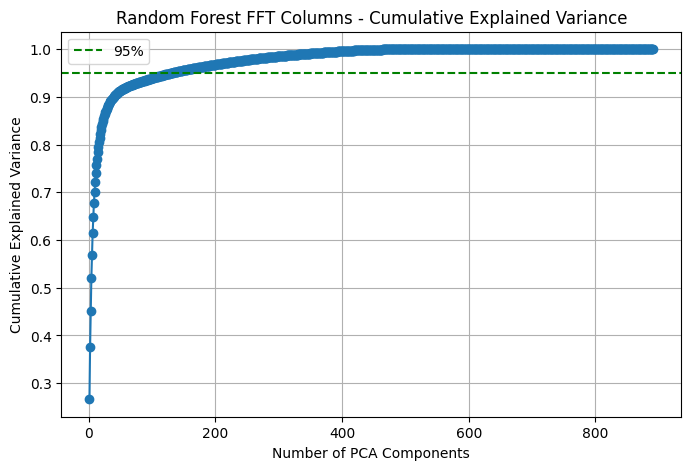

Random Forest PCA - reduce to 130 components (95% explained variance)


In [43]:
scaler_rf = StandardScaler()
X_rf_fft_scaled = scaler_rf.fit_transform(df_fft[rf_fft_selected])
pca_rf = PCA()
pca_rf.fit(X_rf_fft_scaled)
explained_var_rf = np.cumsum(pca_rf.explained_variance_ratio_)
n_components_rf = np.argmax(explained_var_rf >= 0.95) + 1


plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained_var_rf)+1), explained_var_rf, marker='o')
plt.axhline(0.95, color='g', linestyle='--', label='95%')
plt.title('Random Forest FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(f"Random Forest PCA - reduce to {n_components_rf} components (95% explained variance)")

In [44]:
pca_rf_final = PCA(n_components=n_components_rf)
X_rf_final = pca_rf_final.fit_transform(X_rf_fft_scaled)


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Combine the reduced FFT PCA components with the non-FFT features BEFORE splitting
X_rf_combined = np.concatenate([X_rf_final, df_fft[rf_non_fft_selected].values], axis=1)

# Split for Random Forest
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf_combined, y, test_size=0.2, random_state=42, stratify=y)
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_rf_train, y_rf_train)
y_rf_pred = clf_rf.predict(X_rf_test)

print("Random Forest on PCA + non-FFT Data:")
print("Accuracy:", accuracy_score(y_rf_test, y_rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_rf_test, y_rf_pred))
print("Classification Report:\n", classification_report(y_rf_test, y_rf_pred))

Random Forest on PCA + non-FFT Data:
Accuracy: 0.8905497220506485
Confusion Matrix:
 [[3783  297]
 [ 589 3426]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      4080
         1.0       0.92      0.85      0.89      4015

    accuracy                           0.89      8095
   macro avg       0.89      0.89      0.89      8095
weighted avg       0.89      0.89      0.89      8095



Previously base model for random forest was Random Forest  0.862631

In [46]:
# Save the trained model
joblib.dump(clf_rf, "model-checkpoint/random_forest_FSPCA_model.pkl")
print("Model saved successfully!")

Model saved successfully!


### <font color='yellow'>XGBoost</font>

#### Testing 95%

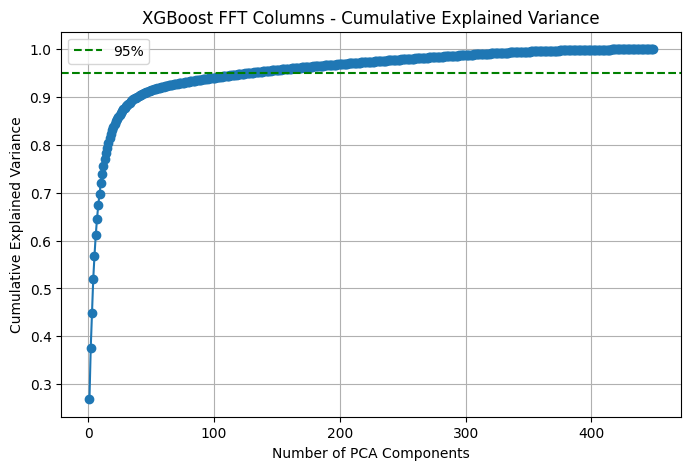

XGBoost PCA - reduced to 128 components


In [47]:
#PCA for XGBoost
scaler_xgb = StandardScaler()
X_xgb_fft_scaled = scaler_xgb.fit_transform(df_fft[xgb_fft_selected])
pca_xgb = PCA()
pca_xgb.fit(X_xgb_fft_scaled)
explained_var_xgb = np.cumsum(pca_xgb.explained_variance_ratio_)
n_components_xgb = np.argmax(explained_var_xgb >= 0.95) + 1

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained_var_xgb)+1), explained_var_xgb, marker='o')
plt.axhline(0.95, color='g', linestyle='--', label='95%')
plt.title('XGBoost FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(f"XGBoost PCA - reduced to {n_components_xgb} components")


In [48]:
pca_xgb_final = PCA(n_components=n_components_xgb)
X_xgb_final = pca_xgb_final.fit_transform(X_xgb_fft_scaled)

In [49]:
# Split for XGBoost

X_xgb_combined = np.concatenate([X_xgb_final, df_fft[xgb_non_fft_selected].values], axis=1)

X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_xgb_combined, y, test_size=0.2, random_state=42, stratify=y)
clf_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
clf_xgb.fit(X_xgb_train, y_xgb_train)
y_xgb_pred = clf_xgb.predict(X_xgb_test)

print("\nXGBoost on PCA + non-FFT Data::")
print("Accuracy:", accuracy_score(y_xgb_test, y_xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_xgb_test, y_xgb_pred))
print("Classification Report:\n", classification_report(y_xgb_test, y_xgb_pred))



XGBoost on PCA + non-FFT Data::
Accuracy: 0.9167387276096356
Confusion Matrix:
 [[3813  267]
 [ 407 3608]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.93      0.92      4080
         1.0       0.93      0.90      0.91      4015

    accuracy                           0.92      8095
   macro avg       0.92      0.92      0.92      8095
weighted avg       0.92      0.92      0.92      8095



Previously base Model for XGBoost was XGBoost Accuracy Score: 0.9219271155033971

In [50]:
# Save the trained model
joblib.dump(clf_xgb, "model-checkpoint/xgboost_FSPCA_model.pkl")
print("Model saved successfully!")

Model saved successfully!


### <font color='yellow'>Decision Tree</font>

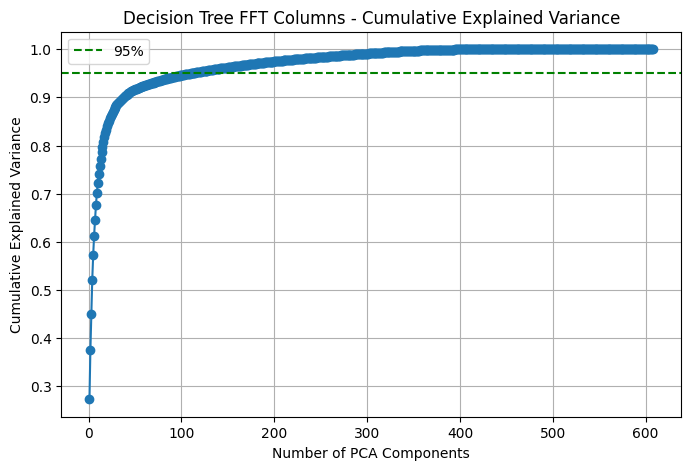

Decision Tree PCA - reduced to 111 components


In [51]:
#PCA for Decision Tree
scaler_dt = StandardScaler()
X_dt_fft_scaled = scaler_dt.fit_transform(df_fft[dt_fft_selected])
pca_dt = PCA()
pca_dt.fit(X_dt_fft_scaled)
explained_var_dt = np.cumsum(pca_dt.explained_variance_ratio_)
n_components_dt = np.argmax(explained_var_dt >= 0.95) + 1

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained_var_dt)+1), explained_var_dt, marker='o')
plt.axhline(0.95, color='g', linestyle='--', label='95%')
plt.title('Decision Tree FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(f"Decision Tree PCA - reduced to {n_components_dt} components")


In [52]:
pca_dt_final = PCA(n_components=n_components_dt)
X_dt_final = pca_dt_final.fit_transform(X_dt_fft_scaled)

In [53]:
# Split for Decision Tree

X_dt_combined = np.concatenate([X_dt_final, df_fft[dt_non_fft_selected].values], axis=1)

X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(X_dt_combined, y, test_size=0.2, random_state=42, stratify=y)
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(X_dt_train, y_dt_train)
y_dt_pred = clf_dt.predict(X_dt_test)
print("\nDecision Tree:")
print("Accuracy:", accuracy_score(y_dt_test, y_dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_dt_test, y_dt_pred))
print("Classification Report:\n", classification_report(y_dt_test, y_dt_pred))


Decision Tree:
Accuracy: 0.8647313156269302
Confusion Matrix:
 [[3551  529]
 [ 566 3449]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.87      0.87      4080
         1.0       0.87      0.86      0.86      4015

    accuracy                           0.86      8095
   macro avg       0.86      0.86      0.86      8095
weighted avg       0.86      0.86      0.86      8095



Previously base model was Decision Tree  0.878443

In [54]:
# Save the trained model
joblib.dump(clf_dt, "model-checkpoint/decision_tree_FSPCA_model.pkl")
print("Model saved successfully!")

Model saved successfully!


## Optimization of codes between XGBoost and Decision Tree

### Random Forest 

In [55]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# GridSearchCV for Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
rf_grid.fit(X_rf_train, y_rf_train)

# Evaluate Random Forest
best_rf = rf_grid.best_estimator_
y_rf_pred = best_rf.predict(X_rf_test)
print("Random Forest (Tuned) on PCA Reduced Data:")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_rf_test, y_rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_rf_test, y_rf_pred))
print("Classification Report:\n", classification_report(y_rf_test, y_rf_pred))


Random Forest (Tuned) on PCA Reduced Data:
Best Parameters: {'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.8910438542310068
Confusion Matrix:
 [[3787  293]
 [ 589 3426]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      4080
         1.0       0.92      0.85      0.89      4015

    accuracy                           0.89      8095
   macro avg       0.89      0.89      0.89      8095
weighted avg       0.89      0.89      0.89      8095



In [56]:
# Save the trained model
joblib.dump(best_rf, "model-checkpoint/bestparams_random_forest_model.pkl")
print("Model saved successfully!")


# Random Forest (Tuned) on PCA Reduced Data:
# Best Parameters: {'class_weight': None, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 120}
# Accuracy: 0.8915379864113651
# Confusion Matrix:
#  [[3786  294]
#  [ 584 3431]]
# Classification Report:
#                precision    recall  f1-score   support

#          0.0       0.87      0.93      0.90      4080
#          1.0       0.92      0.85      0.89      4015

#     accuracy                           0.89      8095
#    macro avg       0.89      0.89      0.89      8095
# weighted avg       0.89      0.89      0.89      8095

Model saved successfully!


### XGBoost

In [57]:
# WITHOUT GPU SUPPORT 
from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10],
    'learning_rate': [0.01, 0.15],
    'subsample': [0.75,1.0],
    'colsample_bytree': [0.75, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), xgb_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
xgb_grid.fit(X_xgb_train, y_xgb_train)

best_xgb = xgb_grid.best_estimator_
y_xgb_pred = best_xgb.predict(X_xgb_test)
print("\nXGBoost (Tuned) on PCA Reduced Data:")
print("Best Parameters:", xgb_grid.best_params_)
print("Accuracy:", accuracy_score(y_xgb_test, y_xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_xgb_test, y_xgb_pred))
print("Classification Report:\n", classification_report(y_xgb_test, y_xgb_pred))

c:\Users\jiawei\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:03:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (Tuned) on PCA Reduced Data:
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 10, 'n_estimators': 300, 'subsample': 1.0}
Accuracy: 0.9206917850525016
Confusion Matrix:
 [[3821  259]
 [ 383 3632]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.94      0.92      4080
         1.0       0.93      0.90      0.92      4015

    accuracy                           0.92      8095
   macro avg       0.92      0.92      0.92      8095
weighted avg       0.92      0.92      0.92      8095



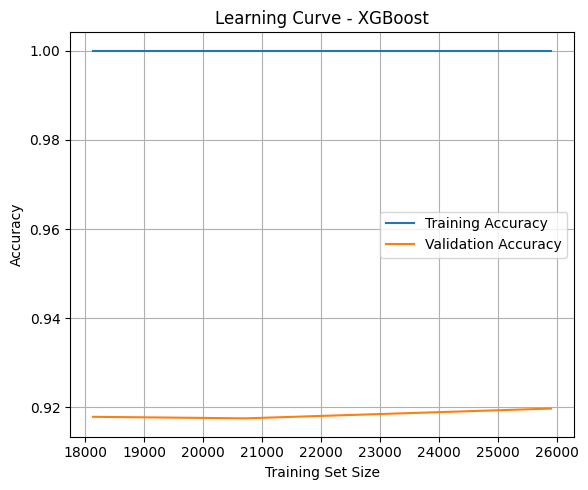

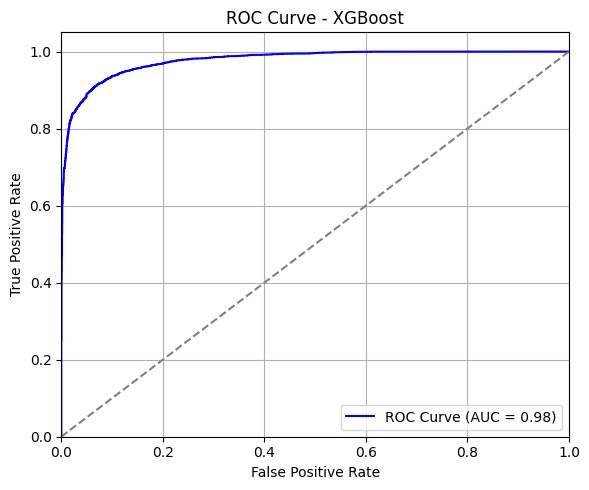

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc

# Learning Curve
def plot_learning_curve(estimator, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=[0.7, 0.8, 1.0], 
        scoring='accuracy', n_jobs=-1
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(6, 5))
    plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
    plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy')
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.title('Learning Curve - XGBoost')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ROC Curve
def plot_roc_curve(estimator, X_test, y_test):
    # Get predicted probabilities for the positive class
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - XGBoost')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Usage
# Assuming you have already performed grid search and have best_xgb
plot_learning_curve(best_xgb, X_xgb_train, y_xgb_train)
plot_roc_curve(best_xgb, X_xgb_test, y_xgb_test)

In [58]:
# # WITH GPU SUPPORT 
# from xgboost import XGBClassifier

# xgb_param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10],
#     'learning_rate': [0.01, 0.15],
#     'subsample': [0.75, 1.0],
#     'colsample_bytree': [0.75, 1.0]
# }

# xgb_grid = GridSearchCV(
#     XGBClassifier(
#         random_state=42,
#         use_label_encoder=False,
#         eval_metric='logloss',
#         tree_method='gpu_hist',
#         predictor='gpu_predictor',
#         gpu_id=0
#     ),
#     xgb_param_grid,
#     cv=5,
#     n_jobs=-1,
#     scoring='accuracy'
# )
# xgb_grid.fit(X_xgb_train, y_xgb_train)

# best_xgb = xgb_grid.best_estimator_
# y_xgb_pred = best_xgb.predict(X_xgb_test)
# print("\nXGBoost (Tuned) on PCA Reduced Data:")
# print("Best Parameters:", xgb_grid.best_params_)
# print("Accuracy:", accuracy_score(y_xgb_test, y_xgb_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_xgb_test, y_xgb_pred))
# print("Classification Report:\n", classification_report(y_xgb_test, y_xgb_pred))


In [59]:
# Save the trained model
joblib.dump(best_xgb, "model-checkpoint/bestparams_xgboost_model.pkl")
print("Model saved successfully!")

Model saved successfully!


### Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
dt_grid.fit(X_dt_train, y_dt_train)

best_dt = dt_grid.best_estimator_
y_dt_pred = best_dt.predict(X_dt_test)
print("\nDecision Tree (Tuned) on PCA Reduced Data:")
print("Best Parameters:", dt_grid.best_params_)
print("Accuracy:", accuracy_score(y_dt_test, y_dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_dt_test, y_dt_pred))
print("Classification Report:\n", classification_report(y_dt_test, y_dt_pred))


Decision Tree (Tuned) on PCA Reduced Data:
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy: 0.8867201976528721
Confusion Matrix:
 [[3735  345]
 [ 572 3443]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.92      0.89      4080
         1.0       0.91      0.86      0.88      4015

    accuracy                           0.89      8095
   macro avg       0.89      0.89      0.89      8095
weighted avg       0.89      0.89      0.89      8095



In [61]:
# Save the trained model
joblib.dump(best_dt, "model-checkpoint/bestparams_decision_tree_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [62]:
# Export the first three decision trees from the forest
# Tree Visualisation

# Load the saved model
clf = joblib.load("model-checkpoint/random_forest_model.pkl")
print("Model loaded successfully!")

# from sklearn.tree import export_graphviz
# from IPython.display import Image
# import graphviz

# for i in range(3):
#     tree = clf.estimators_[i]
#     dot_data = export_graphviz(tree,
#                                feature_names=X_train.columns,  
#                                filled=True,  
#                                max_depth=2, 
#                                impurity=False, 
#                                proportion=True)
#     graph = graphviz.Source(dot_data)
#     display(graph)

Model loaded successfully!


In [63]:
#